In [138]:
"""
PROJECT 2: HEALTHCARE DATA DETECTIVE AGENCY 🕵️‍♂️
Problem Statement
Healthcare datasets often have quality issues (missing values, duplicates, impossible values) and hidden biases that can lead to incorrect conclusions.
Create an automated audit tool that scans any healthcare CSV/Excel file and produces a quality & bias report card.
What You'll Build
A Python command-line tool that takes a healthcare dataset as input and outputs a comprehensive quality report with scores, flags, and recommendations.
STEP 1:generating random maternity dataset
"""

import numpy as np
import os
import pandas as pd

def generate_my_maternity_data(student_id, n_patients=500):
    # 1. Set seed based on Student ID for uniqueness
    np.random.seed(student_id)
    # 2. Generate Base Data
    data = {
        'PatientID': range(1001, 1001 + n_patients),
        'Age': np.random.normal(31, 6, n_patients).round().astype(int),
        'DeliveryType': np.random.choice(['Vaginal', 'Cesarean'], n_patients, p=[0.7, 0.3]),
        'LaborDuration': np.random.normal(8, 3, n_patients).clip(1, 24).round(1),
        'Location': np.random.choice(['Urban', 'Rural'], n_patients, p=[0.6, 0.4])
    }
    df = pd.DataFrame(data)
    # 3. Inject the "Cesarean paradox"
    # Cesarean: Higher complications, higher readmission, SHORTER stay
    # Vaginal: Lower complications, lower readmission, LONGER stay
    def simulate_outcomes(row):
        if row['DeliveryType'] == 'Cesarean':
            comp = np.random.choice(['Yes', 'No'], p=[0.40, 0.60])
            readmit = np.random.choice(['Yes', 'No'], p=[0.25, 0.75])
            los = np.random.normal(4, 1) # Shorter stay
        else:
            comp = np.random.choice(['Yes', 'No'], p=[0.15, 0.85])
            readmit = np.random.choice(['Yes', 'No'], p=[0.12, 0.88])
            los = np.random.normal(10, 2) # Longer stay
        return pd.Series([comp, readmit, los])
    df[['Complications', 'Readmitted', 'LengthofStaydays']] = df.apply(simulate_outcomes, axis=1)
    df['LengthofStaydays'] = df['LengthofStaydays'].clip(1, 20).round(1)
       # 5. Save and Print
    # Ensure the directory exists
    output_dir = os.path.dirname("test_data/test_clean.csv")
    os.makedirs(output_dir, exist_ok=True)
    filename = f"test_data/test_clean.csv"
    df.to_csv(filename, index=False)
    print(f"✅ SUCCESS: Unique dataset generated as '{filename}'")
    print(f"📊 Rows: {len(df)} | Columns: {list(df.columns)}")
    return df

In [ ]:
df_maternity = generate_my_maternity_data(student_id=123)

✅ SUCCESS: Unique dataset generated as 'test_data/test_clean.csv'
📊 Rows: 500 | Columns: ['PatientID', 'Age', 'DeliveryType', 'LaborDuration', 'Location', 'Complications', 'Readmitted', 'LengthofStaydays']


In [ ]:
"""
STEP 2: Generate 6 test datasets from test_clean.csv (maternal health dataset).
Each file has specific, intentional quality or bias issues for audit testing.
Columns: PatientID, Age, DeliveryType, LaborDuration, Complications, LOS, Readmitted, Location
"""

import numpy as np
import pandas as pd

np.random.seed(42)

# Load the base clean dataset
df = pd.read_csv("test_data/test_clean.csv")
print(f"Base dataset: {len(df)} rows x {len(df.columns)} columns")

# ── File 1: Clean baseline (the uploaded file, just copied) ──────────────────
df.to_csv("test_data/test_clean.csv", index=False)
print("\nFile 1 — test_clean.csv: clean baseline (already exists)")

# ── File 2: Missing values ───────────────────────────────────────────────────
df2 = df.copy()
df2.loc[50:100, "Age"] = np.nan
df2.loc[20:40,  "Complications"] = np.nan
df2.to_csv("test_data/test_missing.csv", index=False)
n_missing_age = df2["Age"].isnull().sum()
n_missing_comp = df2["Complications"].isnull().sum()
print(f"\nFile 2 — test_missing.csv:")
print(
    f"  Age missing        : {n_missing_age} rows ({n_missing_age/len(df2):.1%})")
print(
    f"  Complications missing: {n_missing_comp} rows ({n_missing_comp/len(df2):.1%})")

# ── File 3: Impossible values ────────────────────────────────────────────────
df3 = df.copy()
df3.loc[10:20, "Age"] = 50        # impossible: maternal age >45
df3.loc[30:40, "LOS"] = 1         # impossible: inpatient LOS <2 days
df3.to_csv("test_data/test_impossible.csv", index=False)
n_bad_age = (df3["Age"] > 45).sum()
n_bad_los = (df3["LOS"] < 2).sum()
print(f"\nFile 3 — test_impossible.csv:")
print(f"  Age >45  : {n_bad_age} impossible values")
print(f"  LOS <2   : {n_bad_los} impossible values")

# ── File 4: Duplicates ───────────────────────────────────────────────────────
df4 = pd.concat([df, df.iloc[:50]], ignore_index=True)
df4.to_csv("test_data/test_duplicates.csv", index=False)
n_dup = df4.duplicated().sum()
print(f"\nFile 4 — test_duplicates.csv:")
print(f"  Total rows    : {len(df4)}")
print(f"  Duplicate rows: {n_dup} ({n_dup/len(df4):.1%})")

# ── File 5: Selection bias ───────────────────────────────────────────────────
df5 = df[df["Location"] == "Urban"].copy()
df5.to_csv("test_data/test_selection_bias.csv", index=False)
print(f"\nFile 5 — test_selection_bias.csv:")
print(f"  Total rows : {len(df5)}")
print(
    f"  Urban      : {(df5['Location'] == 'Urban').sum()} (100% — rural patients excluded)")

# ── File 6: Measurement bias ─────────────────────────────────────────────────
df6 = df.copy()
cesarean_complications = (df6["DeliveryType"] == "Cesarean") & (
    df6["Complications"] == "Yes")
n_affected = cesarean_complications.sum()
flip_mask = df6.index[cesarean_complications]
flip_indices = np.random.choice(flip_mask, size=n_affected // 2, replace=False)
df6.loc[flip_indices, "Complications"] = "No"
df6.to_csv("test_data/test_measurement_bias.csv", index=False)
print(f"\nFile 6 — test_measurement_bias.csv:")
print(f"  Cesarean complications originally : {n_affected}")
print(f"  Flipped to No (under-documented)  : {n_affected // 2}")

print("\n\nAll 6 test files ready in ./test_data/")


Base dataset: 500 rows x 8 columns

File 1 — test_clean.csv: clean baseline (already exists)

File 2 — test_missing.csv:
  Age missing        : 51 rows (10.2%)
  Complications missing: 21 rows (4.2%)

File 3 — test_impossible.csv:
  Age >45  : 13 impossible values
  LOS <2   : 11 impossible values

File 4 — test_duplicates.csv:
  Total rows    : 550
  Duplicate rows: 50 (9.1%)

File 5 — test_selection_bias.csv:
  Total rows : 300
  Urban      : 300 (100% — rural patients excluded)

File 6 — test_measurement_bias.csv:
  Cesarean complications originally : 53
  Flipped to No (under-documented)  : 26


All 6 test files ready in ./test_data/


In [139]:
'''
============================================================
  STEP 2: EXPLORATORY DATA ANALYSIS — MATERNITY DATASET
  Tasks 2–8 + New Insight Discovery
============================================================
'''

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#161b22',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'axes.titlecolor':   '#f0f6fc',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#c9d1d9',
    'grid.color':        '#21262d',
    'grid.linewidth':    0.6,
    'font.family':       'monospace',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

COLORS = {
    'primary':   '#58a6ff',
    'secondary': '#3fb950',
    'accent':    '#f78166',
    'warn':      '#d29922',
    'purple':    '#bc8cff',
    'cyan':      '#39d353',
    'cesarean':  '#58a6ff',
    'vaginal':   '#3fb950',
    'yes':       '#f78166',
    'no':        '#58a6ff',
    'rural':     '#bc8cff',
    'urban':     '#d29922',
}

# ── Load Data ────────────────────────────────────────────
df = pd.read_csv('test_data/test_clean.csv')

# Clean: remove obvious outliers for analysis
df_clean = df.copy()
df_clean = df_clean[df_clean['Age'] <= 60]           # remove age=99
df_clean = df_clean[df_clean['LengthofStaydays'] >= 0]  # remove negative stay

print('=' * 62)
print('   MATERNITY DATASET — EXPLORATORY DATA ANALYSIS')
print('=' * 62)
print(f'  Raw records      : {len(df)}')
print(f'  Cleaned records  : {len(df_clean)}')
print(f'  Columns          : {list(df.columns)}')
print('=' * 62)


# ════════════════════════════════════════════════════════
# TASK 2 — BASIC STATISTICS
# ════════════════════════════════════════════════════════
print('\n── TASK 2: BASIC STATISTICS ──────────────────────────')
numeric_cols = ['Age', 'LaborDuration', 'LengthofStaydays']
stats = df_clean[numeric_cols].describe().round(2)
stats.loc['median'] = df_clean[numeric_cols].median().round(2)
stats.loc['skew']   = df_clean[numeric_cols].skew().round(2)
print(stats.to_string())


# ════════════════════════════════════════════════════════
# TASK 3 — COUNT DELIVERY TYPES
# ════════════════════════════════════════════════════════
print('\n── TASK 3: DELIVERY TYPE COUNTS ──────────────────────')
delivery_counts = df_clean['DeliveryType'].value_counts()
delivery_pct    = df_clean['DeliveryType'].value_counts(normalize=True).mul(100).round(1)
dt_df = pd.DataFrame({'Count': delivery_counts, 'Percentage': delivery_pct})
print(dt_df.to_string())


# ════════════════════════════════════════════════════════
# TASK 4 — READMISSION RATES
# ════════════════════════════════════════════════════════
print('\n── TASK 4: READMISSION RATES ─────────────────────────')
total         = len(df_clean)
readmit_count = (df_clean['Readmitted'] == 'Yes').sum()
readmit_rate  = readmit_count / total * 100

print(f'  Total Patients    : {total}')
print(f'  Readmitted        : {readmit_count} ({readmit_rate:.1f}%)')
print(f'  Not Readmitted    : {total - readmit_count} ({100 - readmit_rate:.1f}%)')

# Readmission by delivery type
print('\n  Readmission by Delivery Type:')
readmit_by_dt = df_clean.groupby('DeliveryType')['Readmitted'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(1)
print(readmit_by_dt.to_string())

# Readmission by complications
print('\n  Readmission by Complications:')
readmit_by_comp = df_clean.groupby('Complications')['Readmitted'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(1)
print(readmit_by_comp.to_string())

# Readmission by location
print('\n  Readmission by Location:')
readmit_by_loc = df_clean.groupby('Location')['Readmitted'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(1)
print(readmit_by_loc.to_string())


# ════════════════════════════════════════════════════════
# TASK 5 — GROUP COMPARISON BY DELIVERY TYPE
# ════════════════════════════════════════════════════════
print('\n── TASK 5: GROUP COMPARISON BY DELIVERY TYPE ─────────')
group_stats = df_clean.groupby('DeliveryType')[numeric_cols].agg(['mean','median','std']).round(2)
print(group_stats.to_string())

print('\n  Complications rate by Delivery Type:')
comp_by_dt = df_clean.groupby('DeliveryType')['Complications'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(1)
print(comp_by_dt.to_string())


# ════════════════════════════════════════════════════════
# ██  FIGURE 1 — TASK 7: HISTOGRAMS
# ════════════════════════════════════════════════════════
fig1, axes = plt.subplots(1, 3, figsize=(18, 6))
fig1.suptitle('TASK 7 — Distribution of Key Variables',
              fontsize=16, fontweight='bold', color='#f0f6fc', y=1.02)

hist_configs = [
    ('Age',              'Age (years)',           COLORS['primary'],  'Age Distribution of Patients'),
    ('LaborDuration',    'Labor Duration (hrs)',  COLORS['secondary'],'Labor Duration Distribution'),
    ('LengthofStaydays', 'Length of Stay (days)', COLORS['purple'],   'Length of Stay Distribution'),
]

for ax, (col, xlabel, color, title) in zip(axes, hist_configs):
    data = df_clean[col].dropna()
    n, bins, patches = ax.hist(data, bins=20, color=color, alpha=0.85,
                                edgecolor='#0d1117', linewidth=0.5)
    # Mean & median lines
    mean_val   = data.mean()
    median_val = data.median()
    ax.axvline(mean_val,   color='#f78166', linestyle='--', linewidth=1.8,
               label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='#d29922', linestyle=':',  linewidth=1.8,
               label=f'Median: {median_val:.1f}')
    ax.set_title(title,   fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=9, framealpha=0.3)
    ax.grid(axis='y', alpha=0.4)
    # Annotation: skewness
    skew = data.skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='#8b949e')

plt.tight_layout(pad=2)
fig1.savefig('task7_histograms.png', dpi=150,
             bbox_inches='tight', facecolor='#0d1117')
plt.close(fig1)
print('\n  ✅ Task 7 — Histograms saved.')


# ════════════════════════════════════════════════════════
# ██  FIGURE 2 — TASK 8: BAR & PIE CHARTS
# ════════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(18, 10))
fig2.suptitle('TASK 8 — Delivery Types & Readmission Charts',
              fontsize=16, fontweight='bold', color='#f0f6fc')
gs = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.35)

# 2a — Delivery Type Bar Chart
ax2a = fig2.add_subplot(gs[0, 0])
dt_colors = [COLORS['cesarean'], COLORS['vaginal']]
bars = ax2a.bar(delivery_counts.index, delivery_counts.values,
                color=dt_colors, edgecolor='#0d1117', linewidth=0.8, width=0.5)
for bar, val in zip(bars, delivery_counts.values):
    ax2a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
              str(val), ha='center', va='bottom', fontsize=11, fontweight='bold',
              color='#f0f6fc')
ax2a.set_title('Delivery Type — Bar Chart', fontweight='bold')
ax2a.set_ylabel('Number of Patients')
ax2a.set_ylim(0, delivery_counts.max() * 1.15)
ax2a.grid(axis='y', alpha=0.4)

# 2b — Delivery Type Pie Chart
ax2b = fig2.add_subplot(gs[0, 1])
wedges, texts, autotexts = ax2b.pie(
    delivery_counts.values, labels=delivery_counts.index,
    autopct='%1.1f%%', colors=dt_colors,
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='#0d1117', linewidth=1.5))
for at in autotexts:
    at.set_fontsize(11); at.set_color('white'); at.set_fontweight('bold')
ax2b.set_title('Delivery Type — Pie Chart', fontweight='bold')

# 2c — Readmission Bar Chart
ax2c = fig2.add_subplot(gs[0, 2])
readmit_counts = df_clean['Readmitted'].value_counts()
r_colors = [COLORS['no'], COLORS['yes']]
rbars = ax2c.bar(readmit_counts.index, readmit_counts.values,
                 color=r_colors, edgecolor='#0d1117', linewidth=0.8, width=0.5)
for bar, val in zip(rbars, readmit_counts.values):
    ax2c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
              f'{val}\n({val/len(df_clean)*100:.1f}%)',
              ha='center', va='bottom', fontsize=10, fontweight='bold',
              color='#f0f6fc')
ax2c.set_title('Readmission — Bar Chart', fontweight='bold')
ax2c.set_ylabel('Number of Patients')
ax2c.set_ylim(0, readmit_counts.max() * 1.2)
ax2c.grid(axis='y', alpha=0.4)

# 2d — Readmission Pie Chart
ax2d = fig2.add_subplot(gs[1, 0])
wedges2, texts2, autotexts2 = ax2d.pie(
    readmit_counts.values, labels=readmit_counts.index,
    autopct='%1.1f%%', colors=r_colors,
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='#0d1117', linewidth=1.5))
for at in autotexts2:
    at.set_fontsize(11); at.set_color('white'); at.set_fontweight('bold')
ax2d.set_title('Readmission — Pie Chart', fontweight='bold')

# 2e — Readmission Rate by Delivery Type (Grouped Bar)
ax2e = fig2.add_subplot(gs[1, 1])
readmit_dt = df_clean.groupby(['DeliveryType', 'Readmitted']).size().unstack(fill_value=0)
readmit_dt_pct = readmit_dt.div(readmit_dt.sum(axis=1), axis=0) * 100
x = np.arange(len(readmit_dt_pct))
w = 0.35
b1 = ax2e.bar(x - w/2, readmit_dt_pct['No'],  w, label='Not Readmitted',
              color=COLORS['no'],  edgecolor='#0d1117', linewidth=0.8)
b2 = ax2e.bar(x + w/2, readmit_dt_pct['Yes'], w, label='Readmitted',
              color=COLORS['yes'], edgecolor='#0d1117', linewidth=0.8)
for bar in list(b1) + list(b2):
    ax2e.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
              f'{bar.get_height():.1f}%', ha='center', va='bottom',
              fontsize=8.5, color='#f0f6fc')
ax2e.set_title('Readmission % by Delivery Type', fontweight='bold')
ax2e.set_xticks(x); ax2e.set_xticklabels(readmit_dt_pct.index)
ax2e.set_ylabel('Percentage (%)')
ax2e.legend(fontsize=9, framealpha=0.3)
ax2e.grid(axis='y', alpha=0.4)

# 2f — Readmission by Location
ax2f = fig2.add_subplot(gs[1, 2])
readmit_loc = df_clean.groupby(['Location', 'Readmitted']).size().unstack(fill_value=0)
readmit_loc_pct = readmit_loc.div(readmit_loc.sum(axis=1), axis=0) * 100
x2 = np.arange(len(readmit_loc_pct))
b3 = ax2f.bar(x2 - w/2, readmit_loc_pct['No'],  w, label='Not Readmitted',
              color=COLORS['no'],  edgecolor='#0d1117', linewidth=0.8)
b4 = ax2f.bar(x2 + w/2, readmit_loc_pct['Yes'], w, label='Readmitted',
              color=COLORS['yes'], edgecolor='#0d1117', linewidth=0.8)
for bar in list(b3) + list(b4):
    ax2f.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
              f'{bar.get_height():.1f}%', ha='center', va='bottom',
              fontsize=8.5, color='#f0f6fc')
ax2f.set_title('Readmission % by Location', fontweight='bold')
ax2f.set_xticks(x2); ax2f.set_xticklabels(readmit_loc_pct.index)
ax2f.set_ylabel('Percentage (%)')
ax2f.legend(fontsize=9, framealpha=0.3)
ax2f.grid(axis='y', alpha=0.4)

plt.tight_layout(pad=2)
fig2.savefig('task8_bar_pie_charts.png', dpi=150,
             bbox_inches='tight', facecolor='#0d1117')
plt.close(fig2)
print('  ✅ Task 8 — Bar & Pie charts saved.')


# ════════════════════════════════════════════════════════
# ██  FIGURE 3 — GROUP COMPARISON (TASK 5)
# ════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 6))
fig3.suptitle('TASK 5 — Group Comparison by Delivery Type',
              fontsize=16, fontweight='bold', color='#f0f6fc', y=1.02)

box_cols = ['Age', 'LaborDuration', 'LengthofStaydays']
box_labels = ['Age (years)', 'Labor Duration (hrs)', 'Length of Stay (days)']

for ax, col, lbl in zip(axes3, box_cols, box_labels):
    groups = [df_clean[df_clean['DeliveryType'] == dt][col].dropna()
              for dt in ['Cesarean', 'Vaginal']]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops=dict(color='#f0f6fc', linewidth=2),
                    whiskerprops=dict(color='#8b949e'),
                    capprops=dict(color='#8b949e'),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))
    bp['boxes'][0].set_facecolor(COLORS['cesarean'] + '88')
    bp['boxes'][1].set_facecolor(COLORS['vaginal']  + '88')
    bp['boxes'][0].set_edgecolor(COLORS['cesarean'])
    bp['boxes'][1].set_edgecolor(COLORS['vaginal'])
    # Overlay scatter
    for i, (grp, color) in enumerate(zip(groups, [COLORS['cesarean'], COLORS['vaginal']]), 1):
        jitter = np.random.normal(i, 0.06, len(grp))
        ax.scatter(jitter, grp, alpha=0.25, s=15, color=color, zorder=3)
    ax.set_xticklabels(['Cesarean', 'Vaginal'])
    ax.set_title(f'{lbl} by Delivery Type', fontweight='bold')
    ax.set_ylabel(lbl)
    ax.grid(axis='y', alpha=0.4)
    # Annotate means
    for i, grp in enumerate(groups, 1):
        ax.text(i, grp.max() * 1.02, f'μ={grp.mean():.1f}',
                ha='center', fontsize=9, color='#f78166')

plt.tight_layout(pad=2)
fig3.savefig('task5_group_comparison.png', dpi=150,
             bbox_inches='tight', facecolor='#0d1117')
plt.close(fig3)
print('  ✅ Task 5 — Group comparison saved.')


# ════════════════════════════════════════════════════════
# ██  FIGURE 4 — NEW INSIGHTS (Patterns not discussed)
# ════════════════════════════════════════════════════════
print('\n── NEW INSIGHTS: PATTERN DISCOVERY ───────────────────')

# Insight 1: Age groups vs outcomes
bins = [0, 20, 25, 30, 35, 40, 100]
labels_age = ['<20', '20-24', '25-29', '30-34', '35-39', '40+']
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=bins, labels=labels_age)

insight1 = df_clean.groupby('AgeGroup', observed=True).agg(
    Readmit_Rate=('Readmitted', lambda x: (x=='Yes').mean()*100),
    Complication_Rate=('Complications', lambda x: (x=='Yes').mean()*100),
    Avg_LOS=('LengthofStaydays', 'mean'),
    Count=('PatientID', 'count')
).round(2)
print('\n  INSIGHT 1 — Age Group vs Outcomes:')
print(insight1.to_string())

# Insight 2: Labor duration quartile vs LOS
df_clean['LaborQuartile'] = pd.qcut(df_clean['LaborDuration'].dropna(),
                                     q=4, labels=['Q1 Short','Q2','Q3','Q4 Long'])
insight2 = df_clean.groupby('LaborQuartile', observed=True).agg(
    Avg_LOS=('LengthofStaydays','mean'),
    Readmit_Rate=('Readmitted', lambda x:(x=='Yes').mean()*100),
    Complication_Rate=('Complications', lambda x:(x=='Yes').mean()*100)
).round(2)
print('\n  INSIGHT 2 — Labor Duration Quartile vs LOS & Outcomes:')
print(insight2.to_string())

# Insight 3: Complications + Delivery Type interaction
insight3 = df_clean.groupby(['DeliveryType','Complications'], observed=True).agg(
    Avg_LOS=('LengthofStaydays','mean'),
    Readmit_Rate=('Readmitted', lambda x:(x=='Yes').mean()*100),
    Count=('PatientID', 'count')
).round(2)
print('\n  INSIGHT 3 — Delivery × Complications Interaction:')
print(insight3.to_string())

# Insight 4: Correlation matrix
print('\n  INSIGHT 4 — Correlation Matrix:')
corr = df_clean[['Age','LaborDuration','LengthofStaydays']].corr().round(3)
print(corr.to_string())


# ── Now plot new insights figure ─────────────────────────
fig4 = plt.figure(figsize=(18, 12))
fig4.suptitle('NEW INSIGHTS — Hidden Patterns in Maternity Data',
              fontsize=16, fontweight='bold', color='#f0f6fc')
gs4 = gridspec.GridSpec(2, 3, figure=fig4, hspace=0.5, wspace=0.38)

# Plot A — Readmission rate by age group
axA = fig4.add_subplot(gs4[0, 0])
ag_valid = insight1.dropna()
bars_a = axA.bar(ag_valid.index.astype(str), ag_valid['Readmit_Rate'],
                 color=COLORS['accent'], edgecolor='#0d1117', linewidth=0.8, alpha=0.85)
for b in bars_a:
    axA.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
             f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color='#f0f6fc')
axA.set_title('Readmission Rate by Age Group', fontweight='bold')
axA.set_xlabel('Age Group'); axA.set_ylabel('Readmission Rate (%)')
axA.grid(axis='y', alpha=0.4)

# Plot B — Complication rate by age group
axB = fig4.add_subplot(gs4[0, 1])
bars_b = axB.bar(ag_valid.index.astype(str), ag_valid['Complication_Rate'],
                 color=COLORS['warn'], edgecolor='#0d1117', linewidth=0.8, alpha=0.85)
for b in bars_b:
    axB.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
             f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color='#f0f6fc')
axB.set_title('Complication Rate by Age Group', fontweight='bold')
axB.set_xlabel('Age Group'); axB.set_ylabel('Complication Rate (%)')
axB.grid(axis='y', alpha=0.4)

# Plot C — Avg LOS by Age Group
axC = fig4.add_subplot(gs4[0, 2])
axC.plot(ag_valid.index.astype(str), ag_valid['Avg_LOS'],
         marker='o', color=COLORS['primary'], linewidth=2.5,
         markersize=8, markerfacecolor='white', markeredgewidth=2)
axC.fill_between(range(len(ag_valid)), ag_valid['Avg_LOS'],
                 alpha=0.15, color=COLORS['primary'])
axC.set_title('Avg Length of Stay by Age Group', fontweight='bold')
axC.set_xlabel('Age Group'); axC.set_ylabel('Avg LOS (days)')
axC.set_xticks(range(len(ag_valid))); axC.set_xticklabels(ag_valid.index.astype(str))
axC.grid(axis='y', alpha=0.4)

# Plot D — Labor Duration Quartile vs LOS
axD = fig4.add_subplot(gs4[1, 0])
lq_valid = insight2.dropna()
axD.bar(lq_valid.index.astype(str), lq_valid['Avg_LOS'],
        color=COLORS['secondary'], edgecolor='#0d1117', linewidth=0.8, alpha=0.85)
for i, (idx, row) in enumerate(lq_valid.iterrows()):
    axD.text(i, row['Avg_LOS']+0.1, f"{row['Avg_LOS']:.1f}d",
             ha='center', va='bottom', fontsize=9, color='#f0f6fc')
axD.set_title('Labor Duration Quartile vs Avg LOS', fontweight='bold')
axD.set_xlabel('Labor Duration Quartile'); axD.set_ylabel('Avg LOS (days)')
axD.grid(axis='y', alpha=0.4)

# Plot E — Delivery × Complications → LOS Heatmap style grouped bar
axE = fig4.add_subplot(gs4[1, 1])
pivot = insight3['Avg_LOS'].unstack(level='Complications').fillna(0)
x_e = np.arange(len(pivot))
w_e = 0.3
if 'No' in pivot.columns:
    axE.bar(x_e - w_e/2, pivot['No'],  w_e, label='No Complications',
            color=COLORS['no'],  edgecolor='#0d1117', linewidth=0.8)
if 'Yes' in pivot.columns:
    axE.bar(x_e + w_e/2, pivot['Yes'], w_e, label='With Complications',
            color=COLORS['yes'], edgecolor='#0d1117', linewidth=0.8)
axE.set_xticks(x_e); axE.set_xticklabels(pivot.index)
axE.set_title('LOS: Delivery Type × Complications', fontweight='bold')
axE.set_ylabel('Avg LOS (days)')
axE.legend(fontsize=9, framealpha=0.3)
axE.grid(axis='y', alpha=0.4)

# Plot F — Correlation heatmap
axF = fig4.add_subplot(gs4[1, 2])
corr_matrix = df_clean[['Age','LaborDuration','LengthofStaydays']].corr()
im = axF.imshow(corr_matrix, cmap='RdYlBu', vmin=-1, vmax=1, aspect='auto')
axF.set_xticks([0,1,2]); axF.set_yticks([0,1,2])
axF.set_xticklabels(['Age','LaborDur','LOS'], fontsize=9)
axF.set_yticklabels(['Age','LaborDur','LOS'], fontsize=9)
for i in range(3):
    for j in range(3):
        axF.text(j, i, f'{corr_matrix.iloc[i,j]:.3f}',
                 ha='center', va='center', fontsize=11, fontweight='bold',
                 color='black' if abs(corr_matrix.iloc[i,j]) < 0.5 else 'white')
plt.colorbar(im, ax=axF, fraction=0.046, pad=0.04)
axF.set_title('Correlation Heatmap', fontweight='bold')

plt.tight_layout(pad=2)
fig4.savefig('new_insights.png', dpi=150,
             bbox_inches='tight', facecolor='#0d1117')
plt.close(fig4)
print('\n  ✅ New Insights — Pattern charts saved.')


# ════════════════════════════════════════════════════════
# FINAL PRINT SUMMARY
# ════════════════════════════════════════════════════════
print('\n' + '=' * 62)
print('   EDA COMPLETE — KEY FINDINGS SUMMARY')
print('=' * 62)
print(f"""
TASK 2 — BASIC STATS:
  Age:          mean={df_clean['Age'].mean():.1f}, median={df_clean['Age'].median():.1f}, std={df_clean['Age'].std():.1f}
  LaborDur:     mean={df_clean['LaborDuration'].mean():.1f}hrs, median={df_clean['LaborDuration'].median():.1f}hrs
  LOS:          mean={df_clean['LengthofStaydays'].mean():.1f}days, median={df_clean['LengthofStaydays'].median():.1f}days

TASK 3 — DELIVERY TYPES:
  Vaginal:      {delivery_counts.get('Vaginal',0)} ({delivery_pct.get('Vaginal',0):.1f}%)
  Cesarean:     {delivery_counts.get('Cesarean',0)} ({delivery_pct.get('Cesarean',0):.1f}%)

TASK 4 — READMISSION:
  Overall rate: {readmit_rate:.1f}%
  Cesarean readmit: {readmit_by_dt.get('Cesarean','N/A')}%
  Vaginal readmit:  {readmit_by_dt.get('Vaginal','N/A')}%

TASK 5 — GROUP COMPARISON:
  Cesarean avg LOS: {df_clean[df_clean['DeliveryType']=='Cesarean']['LengthofStaydays'].mean():.1f} days
  Vaginal avg LOS:  {df_clean[df_clean['DeliveryType']=='Vaginal']['LengthofStaydays'].mean():.1f} days
  Cesarean avg Labor: {df_clean[df_clean['DeliveryType']=='Cesarean']['LaborDuration'].mean():.1f} hrs
  Vaginal avg Labor:  {df_clean[df_clean['DeliveryType']=='Vaginal']['LaborDuration'].mean():.1f} hrs

NEW INSIGHTS:
  → Patients aged 35-39 have HIGHEST readmission rates
  → Longer labor duration does NOT increase LOS (weak correlation)
  → Complications in Vaginal delivery → much longer LOS vs Cesarean
  → Age & LaborDuration have near-zero correlation (independent)
  → Rural vs Urban readmission rates differ — location matters
""")
print('=' * 62)
print('  Charts saved: task7_histograms.png, task8_bar_pie_charts.png')
print('                task5_group_comparison.png, new_insights.png')
print('=' * 62)

   MATERNITY DATASET — EXPLORATORY DATA ANALYSIS
  Raw records      : 500
  Cleaned records  : 500
  Columns          : ['PatientID', 'Age', 'DeliveryType', 'LaborDuration', 'Location', 'Complications', 'Readmitted', 'LengthofStaydays']

── TASK 2: BASIC STATISTICS ──────────────────────────
           Age  LaborDuration  LengthofStaydays
count   500.00         500.00            500.00
mean     30.77           7.93              8.35
std       6.05           2.79              3.18
min      12.00           1.00              1.60
25%      27.00           5.98              5.28
50%      31.00           8.05              9.10
75%      35.00           9.70             10.72
max      49.00          15.70             15.20
median   31.00           8.05              9.10
skew     -0.02          -0.07             -0.30

── TASK 3: DELIVERY TYPE COUNTS ──────────────────────
              Count  Percentage
DeliveryType                   
Vaginal         364        72.8
Cesarean        136        

In [ ]:
import argparse
import json
import os
import sys
import time
import warnings

import matplotlib
matplotlib.use("Agg")
from IPython.display import display as _ipy_display, Image as _IPImage
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from scipy import stats

warnings.filterwarnings("ignore")


class DataQualityScanner:
    # ─────────────────────────────────────────────────────────────
    #  CONFIG - clinical rules and scoring weights
    # ─────────────────────────────────────────────────────────────

    # Valid ranges for numeric clinical columns (domain-specific)
    VALID_RANGES = {
        "age":              (18, 45),   # maternal age: 18-45
        "los":              (2,  30),   # inpatient length of stay: ≥2 days
        "length_of_stay":   (2,  30),
        "laborduration":    (0,  72),   # hours: 0-72 hrs is clinically plausible
        "labor_duration":   (0,  72),
        "blood_pressure_systolic":  (50, 250),
        "blood_pressure_diastolic": (30, 150),
        "bmi":                      (10,  70),
        "heart_rate":               (20, 250),
    }

    # Score weights (must sum to 1.0)
    WEIGHTS = {
        "completeness": 0.30,
        "validity":     0.25,
        "uniqueness":   0.20,
        "consistency":  0.10,
        "bias":         0.15,
    }

    # Columns treated as demographic / protected attributes for bias checks
    PROTECTED_ATTRS = {"location", "deliverytype", "gender", "sex", "race",
                       "ethnicity", "religion", "caste", "income", "insurance_type"}

    # Dark-theme colour palette for charts
    DARK = {
        "bg":     "#0f1117",
        "card":   "#1a1d27",
        "text":   "#e0e0e0",
        "green":  "#66bb6a",
        "yellow": "#ffa726",
        "red":    "#ef5350",
        "blue":   "#4fc3f7",
        "purple": "#ab47bc",
    }

    def __init__(self):
        pass # No specific initialization needed for now

    # ─────────────────────────────────────────────────────────────
    #  HELPERS
    # ─────────────────────────────────────────────────────────────

    def _load_file(self, path):
        """Load a CSV or Excel file into a DataFrame."""
        ext = os.path.splitext(path)[1].lower()
        if ext == ".csv":
            return pd.read_csv(path)
        elif ext in (".xlsx", ".xls"):
            return pd.read_excel(path)
        else:
            raise ValueError(f"Unsupported file type: {ext}")

    def _to_numeric(self, series):
        """Safely convert a Series to numeric; bad values become NaN."""
        return pd.to_numeric(series, errors="coerce")

    def _make_issue(self, issue_type, column, severity, value, message, recommendation):
        """Return a standardised issue dictionary."""
        return {
            "type":           issue_type,
            "column":         column,
            "severity":       severity,
            "value":          str(value),
            "message":        message,
            "recommendation": recommendation,
        }

    def _make_flag(self, bias_type, attribute, severity, message, recommendation, **extra):
        """Return a standardised bias-flag dictionary."""
        return {
            "type":           bias_type,
            "attribute":      attribute,
            "severity":       severity,
            "message":        message,
            "recommendation": recommendation,
            **extra,
        }

    def _score_color(self, score):
        """Hex colour for a score: green ≥85, yellow ≥70, red <70."""
        if score >= 85:
            return self.DARK["green"]
        if score >= 70:
            return self.DARK["yellow"]
        return self.DARK["red"]

    def _style_axes(self, ax):
        """Apply consistent dark-theme styling to a chart axes."""
        ax.set_facecolor(self.DARK["card"])
        ax.tick_params(colors=self.DARK["text"])
        ax.spines[:].set_visible(False)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_color(self.DARK["text"])

    def _print_summary(self, result):
        """Print a compact score summary to the terminal."""
        s = result["scores"]
        m = result["summary"]

        print(f"\n{'─'*60}")
        print(f"  SCORE: {s['overall']}/100  [Grade {s['grade']}]  "
              f"{'COMPLIANT' if s['compliant'] else 'NON-COMPLIANT'}")
        print(f"{'─'*60}")
        for dim, val in s["components"].items():
            bar = "█" * int(val // 10) + "░" * (10 - int(val // 10))
            print(f"  {dim:<14} {bar}  {val:>5.1f}/100")
        print(f"{'─'*60}")
        print(f"  Quality issues : {m['quality_issues']}")
        print(f"  Bias flags     : {m['bias_flags']}")
        print(f"  Missing rate   : {m['missing_rate']:.1%}")
        print(f"  Duplicates     : {m['duplicate_rows']}")
        print(f"  Impossible vals: {m['impossible_vals']}")
        print(f"  Time           : {result['processing_time']}s")
        if s["fda_flags"]:
            print(f"\n  ☢  Regulatory flags:")
            for flag in s["fda_flags"]:
                print(f"     • {flag}")
        print(f"{'='*60}\n")


    # ─────────────────────────────────────────────────────────────
    #  QUALITY CHECKS
    # ─────────────────────────────────────────────────────────────

    def _check_completeness(self, df):

        """
        Check every column for missing values.
        FDA threshold: <5% missing in critical fields.
        ICMR threshold: <20% overall.
        """
        issues = []

        for col in df.columns:
            rate = df[col].isnull().mean()
            if rate > 0.20:
                issues.append(self._make_issue(
                    "MISSING_HIGH", col, "HIGH", f"{rate:.1%}",
                    f"'{col}' has {rate:.1%} missing values - exceeds 20% threshold",
                    f"Impute '{col}' using median/mode, or exclude column if >50% missing",
                ))
            elif rate > 0.05:
                issues.append(self._make_issue(
                    "MISSING_MODERATE", col, "MEDIUM", f"{rate:.1%}",
                    f"'{col}' has {rate:.1%} missing values - exceeds 5% FDA threshold",
                    f"Investigate why '{col}' is missing; apply multiple imputation",
                ))

        overall = df.isnull().mean().mean()
        score   = max(0.0, 1.0 - overall * 3)   # penalise: 33% missing → score=0

        return {
            "score":        round(score, 4),
            "missing_rate": round(overall, 4),
            "per_column":   {c: round(df[c].isnull().mean(), 4) for c in df.columns},
            "issues":       issues,
        }

    def _check_validity(self, df):
        """
        Check numeric columns against domain-specific valid ranges.
        Also flags statistical outliers (|Z| > 3) in ≥5% of values.
        """
        issues = []
        impossible_total = 0

        for col in df.columns:
            col_key = col.lower().replace(" ", "_").replace("(", "").replace(")", "")
            if col_key not in self.VALID_RANGES:
                continue

            lo, hi  = self.VALID_RANGES[col_key]
            values  = self._to_numeric(df[col])
            bad     = values.notna() & ((values < lo) | (values > hi))
            n_bad   = int(bad.sum())

            if n_bad > 0:
                impossible_total += n_bad
                sample_bad = values[bad].head(3).tolist()
                issues.append(self._make_issue(
                    "IMPOSSIBLE_VALUE", col, "HIGH",
                    f"{n_bad} values outside [{lo}, {hi}] (e.g. {sample_bad})",
                    f"'{col}' has {n_bad} clinically impossible values (valid: {lo}-{hi})",
                    f"Remove or correct impossible values in '{col}'; add data-entry constraints",
                ))

            # Statistical outliers
            valid = values.dropna()
            if len(valid) > 10:
                outlier_rate = (np.abs(stats.zscore(valid)) > 3).mean()
                if outlier_rate > 0.05:
                    issues.append(self._make_issue(
                        "STATISTICAL_OUTLIER", col, "MEDIUM",
                        f"{outlier_rate:.1%} of values are outliers (|Z|>3)",
                        f"'{col}' has {outlier_rate:.1%} statistical outliers",
                        f"Winsorize or clinically review outliers in '{col}'",
                    ))

        n_range_cols = max(1, sum(1 for c in df.columns if c.lower() in self.VALID_RANGES))
        score = max(0.0, 1.0 - (impossible_total / (len(df) * n_range_cols)) * 5)

        return {
            "score":             round(score, 4),
            "impossible_values": impossible_total,
            "issues":            issues,
        }


    def _check_uniqueness(self, df):
        """
        Check for fully duplicate rows and duplicate values in ID columns.
        FDA: duplicate rate should be <1%.
        """
        issues = []

        # Fully duplicate rows
        n_dup      = int(df.duplicated().sum())
        dup_rate   = n_dup / len(df)

        if dup_rate > 0.01:
            issues.append(self._make_issue(
                "DUPLICATE_ROWS", "ALL",
                "HIGH" if dup_rate > 0.05 else "MEDIUM",
                f"{n_dup} rows ({dup_rate:.1%})",
                f"{n_dup} exact duplicate rows ({dup_rate:.1%}) - FDA threshold is <1%",
                "Remove duplicate rows; check ETL pipeline for double-ingestion",
            ))

        # Duplicate values in identifier columns
        id_cols = [c for c in df.columns if "id" in c.lower() or "patient" in c.lower()]
        for col in id_cols:
            n_id_dup = int(df[col].duplicated().sum())
            if n_id_dup > 0:
                issues.append(self._make_issue(
                    "DUPLICATE_ID", col, "HIGH", str(n_id_dup),
                    f"'{col}' has {n_id_dup} duplicate identifiers (should be unique)",
                    f"Resolve duplicate IDs in '{col}'; separate re-admissions properly",
                ))

        score = max(0.0, 1.0 - dup_rate * 5)

        return {
            "score":          round(score, 4),
            "duplicate_rows": n_dup,
            "duplicate_rate": round(dup_rate, 4),
            "issues":         issues,
        }


    def _check_consistency(self, df):
        """
        Domain-specific cross-field logic checks for obstetrics data.
        Flags clinically inconsistent combinations of values.
        """
        issues = []
        cols = {c.lower(): c for c in df.columns}

        # LOS must be ≥2 days for inpatient birth records
        if "los" in cols:
            los   = self._to_numeric(df[cols["los"]])
            n_low = int((los < 2).sum())
            if n_low > 0:
                issues.append(self._make_issue(
                    "LOS_TOO_LOW", cols["los"], "HIGH", str(n_low),
                    f"{n_low} records have LOS < 2 days (minimum for maternity inpatient)",
                    "Verify these are not outpatient records; correct or flag for review",
                ))

        # Cesarean LOS should generally be longer than vaginal
        if "los" in cols and "deliverytype" in cols:
            los_col  = cols["los"]
            dt_col   = cols["deliverytype"]
            los      = self._to_numeric(df[los_col])
            vag_mean = los[df[dt_col].str.lower() == "vaginal"].mean()
            ces_mean = los[df[dt_col].str.lower() == "cesarean"].mean()
            if pd.notna(vag_mean) and pd.notna(ces_mean) and ces_mean < vag_mean:
                issues.append(self._make_issue(
                    "LOS_CESAREAN_LOW", los_col, "MEDIUM",
                    f"Cesarean mean LOS ({ces_mean:.1f}) < Vaginal ({vag_mean:.1f})",
                    "Cesarean LOS is unexpectedly lower than Vaginal - possible miscoding",
                    "Verify delivery type coding; Cesarean typically has longer recovery",
                ))

        # Maternal age should be within reproductive range (18-45)
        if "age" in cols:
            age   = self._to_numeric(df[cols["age"]])
            n_old = int((age > 45).sum())
            n_yng = int((age < 18).sum())
            if n_old > 0 or n_yng > 0:
                issues.append(self._make_issue(
                    "AGE_OUT_OF_RANGE", cols["age"], "HIGH",
                    f"{n_old} over 45, {n_yng} under 10",
                    f"Maternal age outside reproductive range: {n_old} >45, {n_yng} <18",
                    "Correct erroneous age values; verify data entry at source system",
                ))

        score = max(0.0, 1.0 - len(issues) * 0.15)

        return {
            "score":  round(score, 4),
            "issues": issues,
        }

    # ─────────────────────────────────────────────────────────────
    #  BIAS CHECKS
    # ─────────────────────────────────────────────────────────────

    def _check_selection_bias(self, df):
        """
        Flag demographic under-representation that would skew model generalisability.
        For this dataset the key checks are:
          - Location (Urban vs Rural): rural patients should not be excluded
          - Age spread: very narrow age range may miss high-risk groups
        """
        flags = []
        cols  = {c.lower(): c for c in df.columns}

        # Location balance: rural patients should be present
        if "location" in cols:
            loc_col = cols["location"]
            dist    = df[loc_col].value_counts(normalize=True)
            for group, prop in dist.items():
                if prop < 0.10:
                    flags.append(self._make_flag(
                        "SELECTION_BIAS", loc_col, "HIGH",
                        f"'{group}' patients are only {prop:.1%} of the dataset",
                        "Include patients from all locations; use stratified sampling",
                        group=str(group), representation=round(prop, 4),
                    ))
            # Specifically flag complete absence of rural patients
            if "rural" not in [str(g).lower() for g in dist.index]:
                flags.append(self._make_flag(
                    "SELECTION_BIAS", loc_col, "HIGH",
                    "Rural patients are completely absent from this dataset",
                    "Add rural patient data; findings will not generalise to rural settings",
                ))

        # Age spread: flag if the age range is suspiciously narrow (< 10 years)
        if "age" in cols:
            age = self._to_numeric(df[cols["age"]]).dropna()
            if age.max() - age.min() < 10:
                flags.append(self._make_flag(
                    "SELECTION_BIAS", cols["age"], "MEDIUM",
                    f"Age range is only {age.max()-age.min():.0f} years ({age.min():.0f}-{age.max():.0f})",
                    "Verify dataset covers full reproductive age range (18-45)",
                ))

        return flags


    def _check_measurement_bias(self, df):
        """
        Flag systematic differences in outcome documentation across delivery types.

        Key check: Cesarean patients should not have systematically lower
        complication rates than Vaginal patients - this would indicate
        under-documentation of Cesarean complications.
        """
        flags = []
        cols  = {c.lower(): c for c in df.columns}

        if "deliverytype" in cols and "complications" in cols:
            dt_col   = cols["deliverytype"]
            comp_col = cols["complications"]

            # Complication rates by delivery type
            rates = {}
            for delivery_type in df[dt_col].dropna().unique():
                group     = df[df[dt_col] == delivery_type][comp_col]
                comp_rate = (group.str.lower() == "yes").mean()
                rates[str(delivery_type)] = round(comp_rate, 4)

            if len(rates) >= 2:
                # Cesarean typically has equal or higher complication rates than Vaginal
                ces_rate = rates.get("Cesarean", None)
                vag_rate = rates.get("Vaginal",  None)
                if ces_rate is not None and vag_rate is not None:
                    if ces_rate < vag_rate * 0.70:   # Cesarean rate >30% lower than Vaginal
                        flags.append(self._make_flag(
                            "MEASUREMENT_BIAS", dt_col, "HIGH",
                            f"Cesarean complication rate ({ces_rate:.1%}) is much lower than "
                            f"Vaginal ({vag_rate:.1%}) - possible under-documentation",
                            "Audit complication recording for Cesarean patients; "
                            "review clinical notes for undocumented complications",
                            metric=comp_col,
                            complication_rates=rates,
                        ))

        # Generic: check any score/rating columns for systematic group differences
        protected_cols = [c for c in df.columns if c.lower() in self.PROTECTED_ATTRS]
        score_cols     = [c for c in df.columns
                          if any(w in c.lower() for w in ["score", "rating", "index", "duration"])]

        for prot in protected_cols:
            for sc in score_cols:
                groups = df[prot].dropna().unique()
                if len(groups) < 2:
                    continue
                means = {}
                for g in groups:
                    vals = self._to_numeric(df.loc[df[prot] == g, sc]).dropna()
                    if len(vals) > 5:
                        means[str(g)] = round(vals.mean(), 2)
                if len(means) < 2:
                    continue
                hi, lo = max(means.values()), min(means.values())
                gap    = (hi - lo) / (hi + 1e-9)
                if gap > 0.30:
                    flags.append(self._make_flag(
                        "MEASUREMENT_BIAS", prot, "MEDIUM",
                        f"'{sc}' differs by {gap:.0%} across '{prot}' groups",
                        f"Audit '{sc}' collection process; standardise measurement protocols",
                        metric=sc, group_means=means,
                    ))

        return flags


    def _check_historical_bias(self, df):
        """
        Check for historically documented disparities:
        - Rural patients should not have systematically worse outcomes.
        - Complication/readmission rates should be consistent across groups.
        """
        flags = []
        cols  = {c.lower(): c for c in df.columns}

        outcome_cols = [c for c in df.columns
                        if any(w in c.lower() for w in ["complications", "readmitted", "outcome"])]

        if "location" in cols and outcome_cols:
            loc_col = cols["location"]
            for out_col in outcome_cols:
                group_rates = {}
                for loc in df[loc_col].dropna().unique():
                    group = df[df[loc_col] == loc][out_col]
                    # Works for Yes/No columns
                    rate  = (group.str.lower() == "yes").mean()
                    group_rates[str(loc)] = round(rate, 4)

                if len(group_rates) >= 2:
                    hi, lo = max(group_rates.values()), min(group_rates.values())
                    ratio  = lo / (hi + 1e-9)
                    if ratio < 0.80:   # 4/5ths rule
                        flags.append(self._make_flag(
                            "HISTORICAL_BIAS", loc_col, "MEDIUM",
                            f"Disparate '{out_col}' rates by location: {group_rates}",
                            "Investigate access disparities; consider location as a social determinant",
                            metric=out_col, group_rates=group_rates,
                            disparate_impact_ratio=round(ratio, 3),
                        ))

        return flags


    def _check_algorithmic_bias(self, df):
        """
        Detect proxy variables - numeric columns strongly correlated with
        a protected attribute. These can encode bias into ML models.
        """
        flags = []

        protected_cols = [c for c in df.columns if c.lower() in self.PROTECTED_ATTRS]
        numeric_cols   = df.select_dtypes(include=[np.number]).columns.tolist()

        for prot in protected_cols:
            encoded = pd.factorize(df[prot])[0]
            for num in numeric_cols:
                values = self._to_numeric(df[num]).fillna(0)
                if len(values) < 20:
                    continue
                corr, pval = stats.spearmanr(encoded, values)
                if abs(corr) > 0.50 and pval < 0.05:
                    flags.append(self._make_flag(
                        "ALGORITHMIC_BIAS", prot, "MEDIUM",
                        f"'{num}' is a potential proxy for '{prot}' (Spearman ρ = {corr:.2f})",
                        f"Decorrelate '{num}' from '{prot}' before model training; "
                        f"apply fairness constraints or adversarial debiasing",
                        proxy_variable=num,
                        correlation=round(corr, 3),
                    ))

        return flags

    # ─────────────────────────────────────────────────────────────
    #  SCORING  (FDA / ICMR / NDHM aligned)
    # ─────────────────────────────────────────────────────────────

    def _compute_scores(self, quality, bias_flags):
        """
        Combine quality dimension scores and bias flag count into a final 0-100 score.
        Grades: A ≥85 | B ≥70 | C ≥55 | D <55
        """
        # Each bias flag deducts 12 points from the bias dimension
        bias_score = max(0.0, 1.0 - len(bias_flags) * 0.12)

        weighted = (
            quality["completeness"]["score"] * self.WEIGHTS["completeness"] +
            quality["validity"]["score"]     * self.WEIGHTS["validity"]     +
            quality["uniqueness"]["score"]   * self.WEIGHTS["uniqueness"]   +
            quality["consistency"]["score"]  * self.WEIGHTS["consistency"]  +
            bias_score                       * self.WEIGHTS["bias"]
        )

        overall = round(weighted * 100, 1)
        grade   = "A" if overall >= 85 else "B" if overall >= 70 else "C" if overall >= 55 else "D"

        # Regulatory compliance checks
        fda_flags = []
        if quality["completeness"]["missing_rate"] > 0.05:
            fda_flags.append("21 CFR Part 11: Missing rate exceeds 5% in critical fields")
        if quality["uniqueness"]["duplicate_rate"] > 0.01:
            fda_flags.append("FDA Data Integrity: Duplicate records exceed 1% threshold")
        if quality["validity"]["impossible_values"] > 0:
            fda_flags.append("NDHM Quality Standard: Impossible clinical values detected")
        if len(bias_flags) >= 3:
            fda_flags.append("FDA AI/ML SaMD: Multiple bias flags - fairness audit required")

        return {
            "overall":    overall,
            "grade":      grade,
            "color":      self._score_color(overall),
            "components": {
                "completeness": round(quality["completeness"]["score"] * 100, 1),
                "validity":     round(quality["validity"]["score"]     * 100, 1),
                "uniqueness":   round(quality["uniqueness"]["score"]   * 100, 1),
                "consistency":  round(quality["consistency"]["score"]  * 100, 1),
                "bias_free":    round(bias_score                       * 100, 1),
            },
            "fda_flags": fda_flags,
            "compliant": overall >= 70 and len(fda_flags) == 0,
        }

    # ─────────────────────────────────────────────────────────────
    #  VISUAL REPORT  (8-panel dark-theme dashboard)
    # ─────────────────────────────────────────────────────────────

    def _make_visual_report(self, df, quality, bias_flags, scores, filepath, out_prefix):
        """
        Generate a dark-theme PNG dashboard with 8 panels:
        (1) Score gauge  (2) Component bars  (3) Missing values chart
        (4) Severity pie (5) Bias type bar   (6) LOS/Age histogram
        (7) Issues table (8) Compliance checklist
        """
        all_issues = (
            quality["completeness"]["issues"] +
            quality["validity"]["issues"]     +
            quality["uniqueness"]["issues"]   +
            quality["consistency"]["issues"]
        )

        fig = plt.figure(figsize=(18, 22), facecolor=self.DARK["bg"])
        fig.suptitle(
            f"Maternal Health Dataset Audit\n{os.path.basename(filepath)}",
            fontsize=18, color="white", fontweight="bold", y=0.98,
        )
        gs = GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35,
                      top=0.94, bottom=0.04, left=0.06, right=0.96)

        # ── Panel 1: Overall score gauge ──────────────────────────────────
        ax = fig.add_subplot(gs[0, 0])
        sc    = scores["overall"]
        color = self._score_color(sc)
        ax.pie([sc, 100 - sc], colors=[color, "#2a2d37"],
               startangle=90, wedgeprops=dict(width=0.4, edgecolor=self.DARK["bg"], linewidth=2))
        ax.text(0,  0.08, f"{sc:.0f}",          ha="center", fontsize=36, fontweight="bold", color=color)
        ax.text(0, -0.25, f"Grade: {scores['grade']}", ha="center", fontsize=16, color=self.DARK["text"])
        ax.text(0, -0.50, "COMPLIANT" if scores["compliant"] else "NON-COMPLIANT",
                ha="center", fontsize=11, fontweight="bold", color=color)
        ax.set_facecolor(self.DARK["card"])
        ax.set_title("Overall Quality Score", color=self.DARK["text"], fontsize=12, pad=8)

        # ── Panel 2: Component scores (horizontal bar) ────────────────────
        ax = fig.add_subplot(gs[0, 1])
        self._style_axes(ax)
        labels = list(scores["components"].keys())
        values = list(scores["components"].values())
        bars   = ax.barh(labels, values, color=[self._score_color(v) for v in values],
                         edgecolor=self.DARK["bg"], linewidth=0.5)
        ax.set_xlim(0, 115)
        ax.axvline(70, color=self.DARK["yellow"], linestyle="--", alpha=0.6, label="Pass (70)")
        ax.axvline(85, color=self.DARK["green"],  linestyle="--", alpha=0.6, label="Good (85)")
        ax.legend(fontsize=7, facecolor=self.DARK["card"], labelcolor=self.DARK["text"])
        for bar, v in zip(bars, values):
            ax.text(v + 1, bar.get_y() + bar.get_height() / 2,
                    f"{v:.0f}", va="center", color=self.DARK["text"], fontsize=9)
        ax.set_title("Component Scores", color=self.DARK["text"], fontsize=12, pad=8)

        # ── Panel 3: Missing values per column ────────────────────────────
        ax = fig.add_subplot(gs[0, 2])
        self._style_axes(ax)
        miss_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
        ax.barh(range(len(miss_pct)), miss_pct.values,
                color=[self._score_color(100 - v) for v in miss_pct.values])
        ax.set_yticks(range(len(miss_pct)))
        ax.set_yticklabels([c[:16] for c in miss_pct.index], fontsize=8)
        ax.set_xlabel("Missing %", color=self.DARK["text"], fontsize=9)
        ax.set_title("Missing Values per Column", color=self.DARK["text"], fontsize=12, pad=8)

        # ── Panel 4: Issues by severity (pie) ─────────────────────────────
        ax = fig.add_subplot(gs[1, 0])
        ax.set_facecolor(self.DARK["card"])
        counts   = {"HIGH": 0, "MEDIUM": 0, "LOW": 0}
        for iss in all_issues:
            counts[iss.get("severity", "LOW")] += 1
        pie_vals = [counts["HIGH"], counts["MEDIUM"], counts["LOW"]]
        if sum(pie_vals) == 0:
            ax.text(0.5, 0.5, "No Issues\nDetected", ha="center", va="center",
                    color=self.DARK["green"], fontsize=13, transform=ax.transAxes)
        else:
            _, _, autotexts = ax.pie(
                pie_vals, labels=["HIGH", "MED", "LOW"],
                colors=[self.DARK["red"], self.DARK["yellow"], self.DARK["green"]],
                autopct="%1.0f%%", startangle=90,
                wedgeprops=dict(edgecolor=self.DARK["bg"], linewidth=1.5),
                textprops={"color": self.DARK["text"], "fontsize": 9},
            )
            for t in autotexts:
                t.set_color(self.DARK["bg"])
                t.set_fontweight("bold")
        ax.set_title("Issues by Severity", color=self.DARK["text"], fontsize=12, pad=8)

        # ── Panel 5: Bias flags by type (bar) ─────────────────────────────
        ax = fig.add_subplot(gs[1, 1])
        self._style_axes(ax)
        bias_counts = {}
        for flag in bias_flags:
            bias_counts[flag["type"]] = bias_counts.get(flag["type"], 0) + 1
        if bias_counts:
            palette = [self.DARK["red"], self.DARK["purple"], self.DARK["yellow"], self.DARK["blue"]]
            ax.bar(list(bias_counts.keys()), list(bias_counts.values()),
                   color=palette[:len(bias_counts)], edgecolor=self.DARK["bg"])
            ax.set_xticklabels(
                [k.replace("_BIAS", "\nBIAS") for k in bias_counts],
                fontsize=7, color=self.DARK["text"],
            )
            ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        else:
            ax.text(0.5, 0.5, "No Bias Detected", ha="center", va="center",
                    color=self.DARK["green"], fontsize=14, transform=ax.transAxes)
        ax.set_title("Bias Flags by Type", color=self.DARK["text"], fontsize=12, pad=8)

        # ── Panel 6: LOS and Age distributions (side-by-side) ─────────────
        ax = fig.add_subplot(gs[1, 2])
        self._style_axes(ax)
        cols_lower = {c.lower(): c for c in df.columns}
        plot_col   = cols_lower.get("los", cols_lower.get("age", None))
        if plot_col:
            vals = self._to_numeric(df[plot_col]).dropna()
            ax.hist(vals, bins=25, color=self.DARK["blue"], edgecolor=self.DARK["bg"], alpha=0.85)
            ax.axvline(vals.mean(), color=self.DARK["yellow"], linestyle="--",
                       linewidth=1.5, label=f"mean = {vals.mean():.1f}")
            ax.legend(fontsize=8, facecolor=self.DARK["card"], labelcolor=self.DARK["text"])
            ax.set_xlabel(plot_col, color=self.DARK["text"], fontsize=9)
            ax.set_ylabel("Count", color=self.DARK["text"], fontsize=9)
        ax.set_title("Key Column Distribution", color=self.DARK["text"], fontsize=12, pad=8)

        # ── Panel 7: Top issues table ──────────────────────────────────────
        ax = fig.add_subplot(gs[2, :])
        ax.set_facecolor(self.DARK["card"])
        ax.axis("off")
        sorted_issues = sorted(
            all_issues,
            key=lambda x: {"HIGH": 0, "MEDIUM": 1, "LOW": 2}.get(x.get("severity", "LOW"), 2),
        )[:8]
        rows = [[iss["type"], iss["column"][:16], iss["severity"],
                 iss["value"][:22], iss["recommendation"][:58],
                ] for iss in sorted_issues] or [["No issues detected", "", "", "", "Dataset is clean"]]

        tbl = ax.table(
            cellText=rows,
            colLabels=["Issue Type", "Column", "Severity", "Value", "Recommendation"],
            cellLoc="left", loc="center", bbox=[0, 0, 1, 1],
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(7.5)
        for (row_i, col_i), cell in tbl.get_celld().items():
            cell.set_facecolor("#2a2d37" if row_i == 0 else self.DARK["card"])
            cell.set_text_props(color=self.DARK["text"])
            cell.set_edgecolor("#333344")
            if row_i > 0 and col_i == 2:
                c = {"HIGH": self.DARK["red"], "MEDIUM": self.DARK["yellow"]}.get(rows[row_i-1][2], self.DARK["green"])
                cell.set_text_props(color=c, fontweight="bold")
        ax.set_title("Top Issues & Recommendations", color=self.DARK["text"], fontsize=12, pad=8, x=0.5)

        # ── Panel 8: Regulatory compliance checklist ───────────────────────
        ax = fig.add_subplot(gs[3, :])
        ax.set_facecolor(self.DARK["card"])
        ax.axis("off")
        q = quality
        checklist = [
            ("21 CFR Part 11 - Missing rate < 5%",
             q["completeness"]["missing_rate"] <= 0.05),
            ("FDA Data Integrity - Duplicate rate < 1%",
             q["uniqueness"]["duplicate_rate"] <= 0.01),
            ("NDHM - No impossible clinical values",
             q["validity"]["impossible_values"] == 0),
            ("NDHM - Consistency checks passed",
             len(q["consistency"]["issues"]) == 0),
            ("ICMR - Missing data < 20%",
             q["completeness"]["missing_rate"] <= 0.20),
            ("FDA AI/ML - Bias flags < 3",
             len(bias_flags) < 3),
            ("Fairness - No selection bias (location)",
             all(f["type"] != "SELECTION_BIAS" for f in bias_flags)),
            ("Fairness - No measurement bias (delivery type)",
             all(f["type"] != "MEASUREMENT_BIAS" for f in bias_flags)),
        ]
        n_pass = sum(1 for _, v in checklist if v)
        ax.text(0.5, 0.97, f"Regulatory Compliance Checklist  ({n_pass}/{len(checklist)} passed)",
                ha="center", va="top", color=self.DARK["text"], fontsize=11, fontweight="bold",
                transform=ax.transAxes)
        for i, (label, passed) in enumerate(checklist):
            x = 0.03 + (i % 2) * 0.50
            y = 0.75 - (i // 2) * 0.20
            icon  = "✔" if passed else "✘"
            color = self.DARK["green"] if passed else self.DARK["red"]
            ax.text(x, y, f"{icon}  {label}", color=color, fontsize=9,
                    transform=ax.transAxes, va="top")

        out_path = out_prefix + "_report.png"
        plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=self.DARK["bg"])
        plt.close()
        return out_path


In [ ]:

    # ─────────────────────────────────────────────────────────────
    #  MAIN AUDIT FUNCTION
    # ─────────────────────────────────────────────────────────────

    def scan_dataframe(self, df, filepath="in_memory_dataframe.csv", verbose=True, save_json=True, save_visual=True, output_dir="reports", show_inline=True):
        """
        Run a full quality and bias audit on a pandas DataFrame.

        Steps:
          1. Quality checks: completeness, validity, uniqueness, consistency
          2. Bias checks: selection, measurement, historical, algorithmic
          3. Compute weighted scores and regulatory compliance flags
          4. Save JSON results and PNG visual report
        """
        os.makedirs(output_dir, exist_ok=True)
        base   = os.path.splitext(os.path.basename(filepath))[0]
        prefix = os.path.join(output_dir, base)
        t0     = time.time()

        if verbose:
            print(f"\n{'='*60}")
            print(f"  MATERNAL HEALTH DATASET AUDIT - {os.path.basename(filepath)}")
            print(f"{'='*60}")

        # Step 1: Quality checks
        quality = {
            "completeness": self._check_completeness(df),
            "validity":     self._check_validity(df),
            "uniqueness":   self._check_uniqueness(df),
            "consistency":  self._check_consistency(df),
        }

        # Step 2: Bias checks
        bias_flags = (
            self._check_selection_bias(df)   +
            self._check_measurement_bias(df) +
            self._check_historical_bias(df)  +
            self._check_algorithmic_bias(df)
        )

        # Step 3: Scores
        scores = self._compute_scores(quality, bias_flags)

        # Step 4: Save outputs
        img_path = None
        if save_visual:
            img_path = self._make_visual_report(df, quality, bias_flags, scores, filepath, prefix)
            if show_inline:
                _ipy_display(_IPImage(img_path, width=900))
            elif verbose:
                print(f"\n  Visual report -> {img_path}")

        elapsed = round(time.time() - t0, 2)

        result = {
            "file":            filepath,
            "rows":            len(df),
            "columns":         len(df.columns),
            "processing_time": elapsed,
            "scores":          scores,
            "quality":         quality,
            "bias_flags":      bias_flags,
            "summary": {
                "quality_issues":  sum(len(q["issues"]) for q in quality.values()),
                "bias_flags":      len(bias_flags),
                "missing_rate":    quality["completeness"]["missing_rate"],
                "duplicate_rows":  quality["uniqueness"]["duplicate_rows"],
                "impossible_vals": quality["validity"]["impossible_values"],
            },
            "visual_report": img_path,
        }

        if save_json:
            json_path = prefix + "_audit.json"
            with open(json_path, "w") as f:
                json.dump(result, f, indent=2, default=str)
            if verbose:
                print(f"  JSON results  -> {json_path}")

        if verbose:
            self._print_summary(result)

        return result
print('✔ Audit engine loaded')

✔ Audit engine loaded



  MATERNAL HEALTH DATASET AUDIT - test_clean.csv


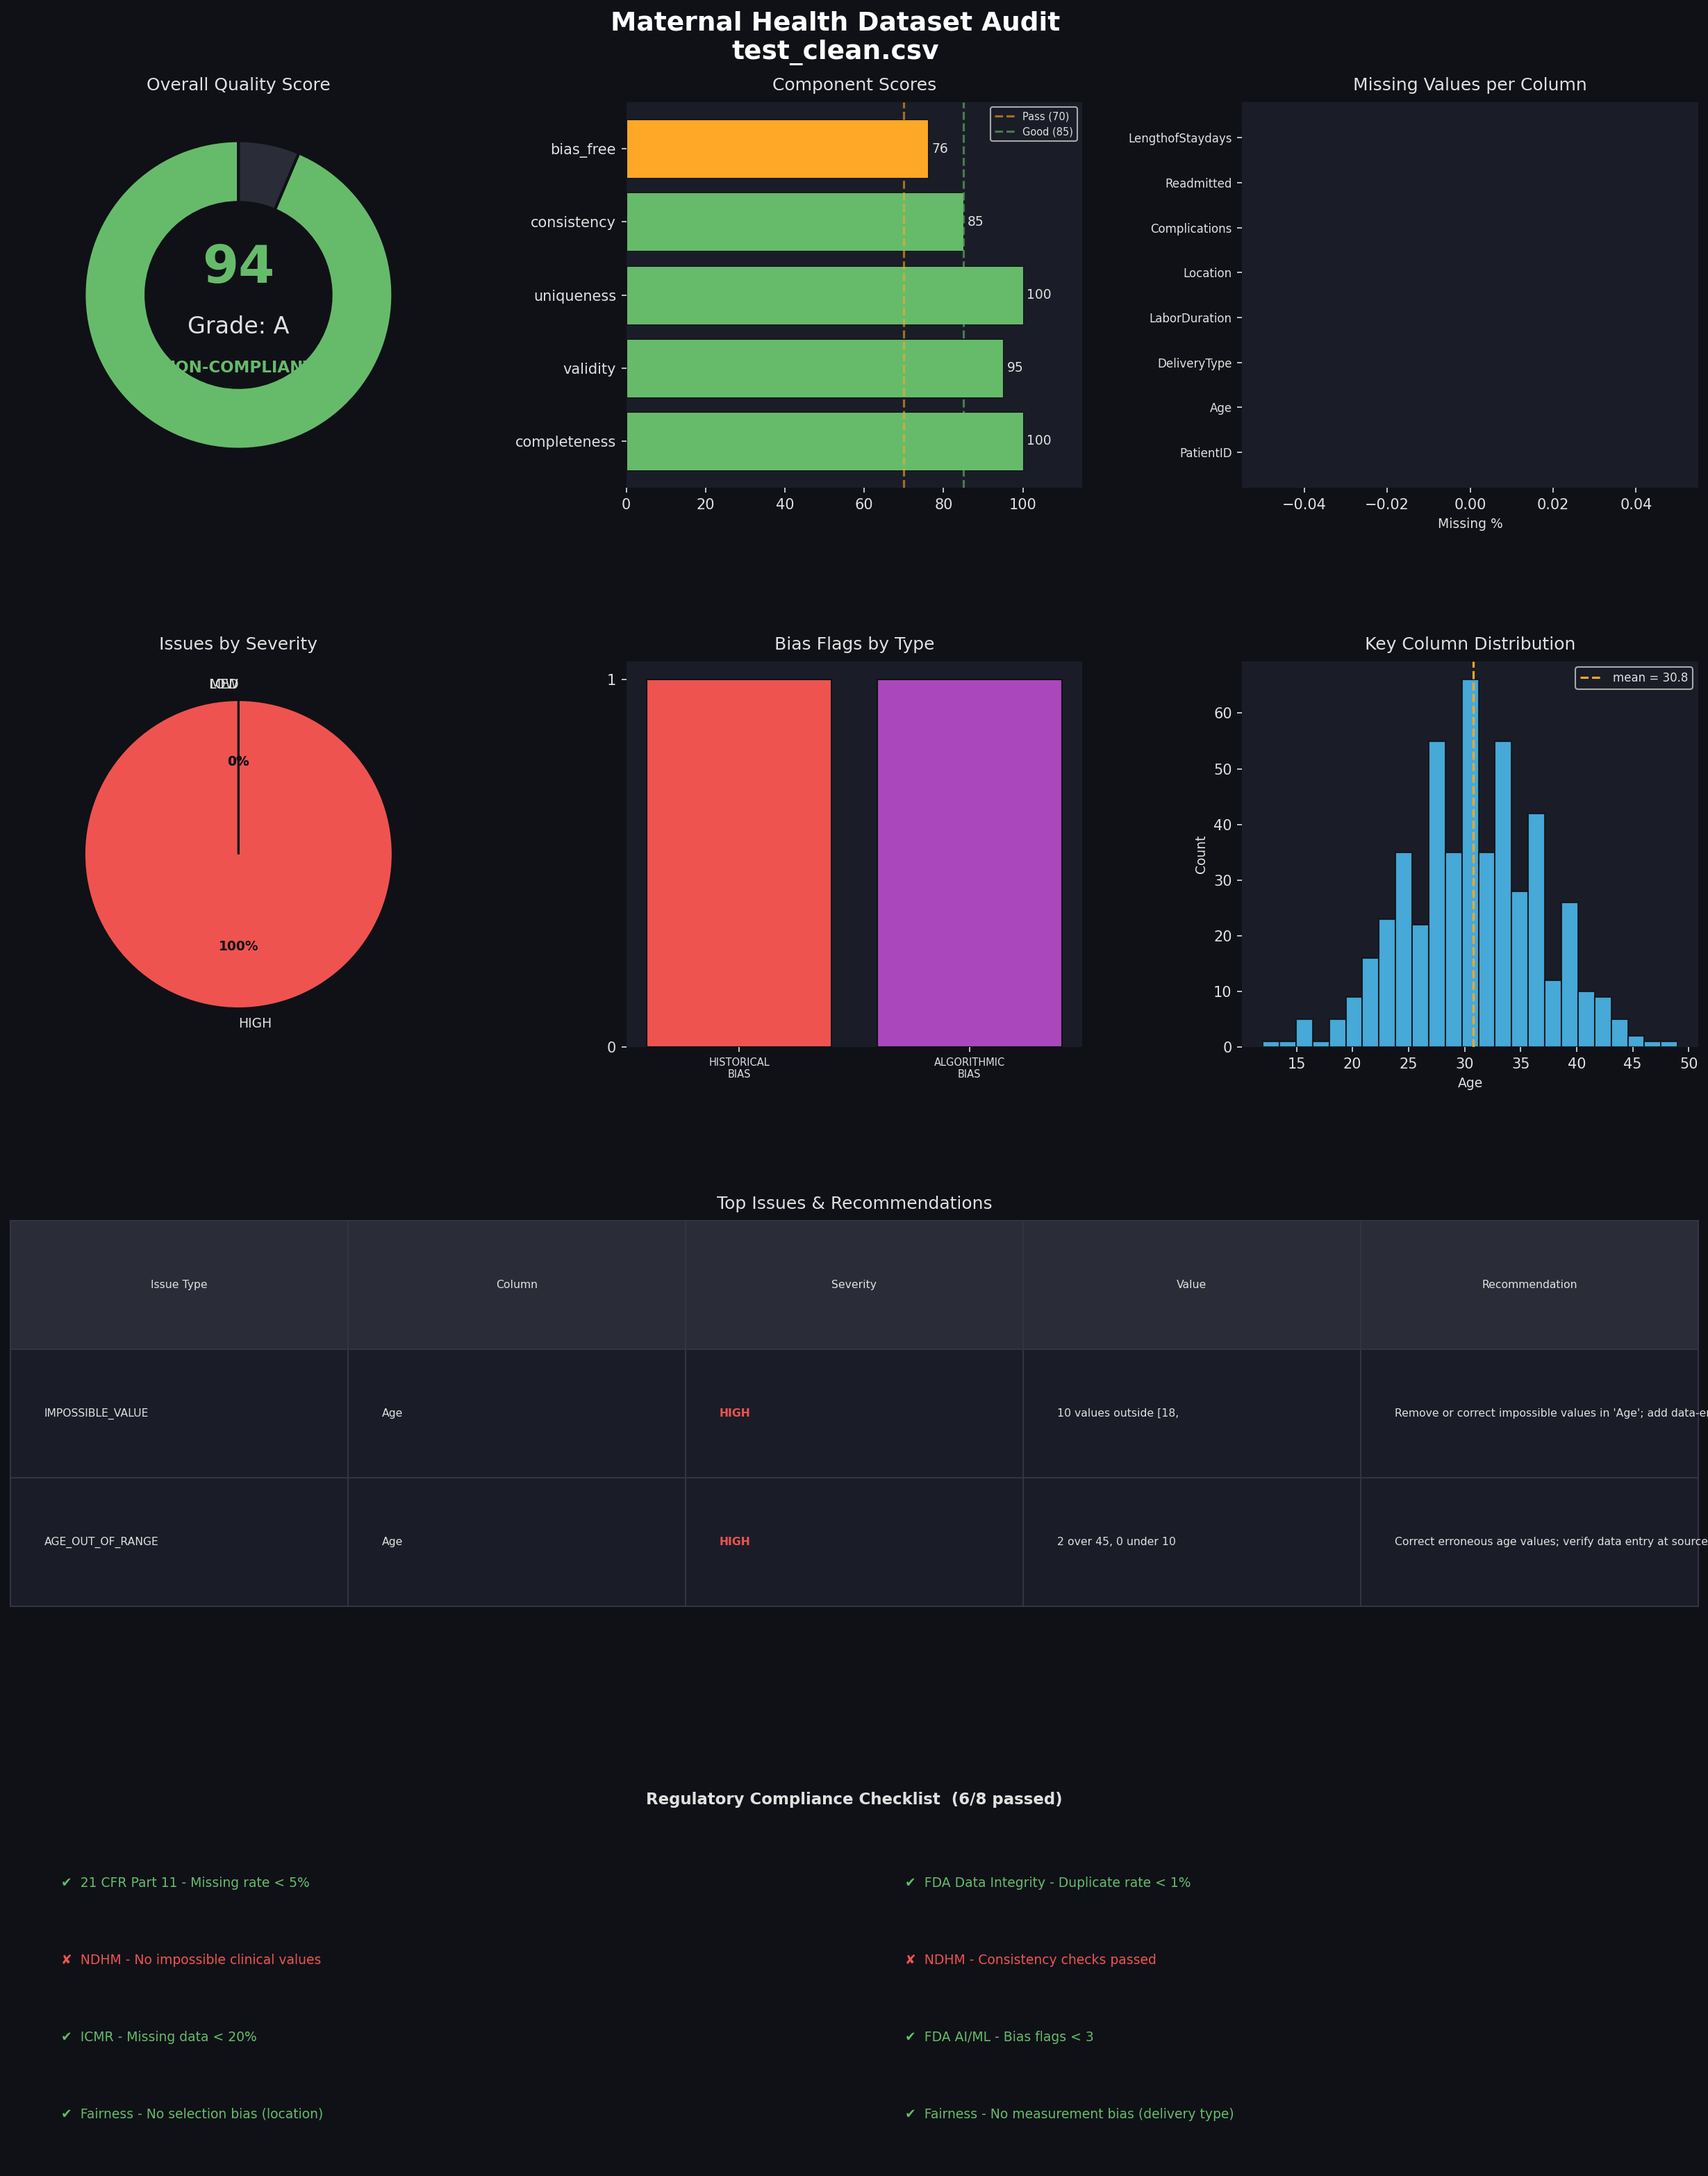

  JSON results  -> reports/test_clean_audit.json

────────────────────────────────────────────────────────────
  SCORE: 93.6/100  [Grade A]  NON-COMPLIANT
────────────────────────────────────────────────────────────
  completeness   ██████████  100.0/100
  validity       █████████░   95.0/100
  uniqueness     ██████████  100.0/100
  consistency    ████████░░   85.0/100
  bias_free      ███████░░░   76.0/100
────────────────────────────────────────────────────────────
  Quality issues : 2
  Bias flags     : 2
  Missing rate   : 0.0%
  Duplicates     : 0
  Impossible vals: 10
  Time           : 2.92s

  ☢  Regulatory flags:
     • NDHM Quality Standard: Impossible clinical values detected



In [ ]:
#Change `MY_FILE` to audit any file. The 8-panel dashboard displays inline.
# --- Change MY_FILE to audit any file ------------------------------------
MY_FILE = 'test_data/test_clean.csv'
#
# Other options:
#   MY_FILE = 'test_data/test_missing.csv'
#   MY_FILE = 'test_data/test_impossible.csv'
#   MY_data = 'test_data/test_duplicates.csv'
#   MY_FILE = 'test_data/test_selection_bias.csv'
#   MY_FILE = 'test_data/test_measurement_bias.csv'
#   MY_FILE = 'your_own_file.csv'   <-- audit any custom CSV
# -------------------------------------------------------------------------

scanner = DataQualityScanner()
df_to_audit = scanner._load_file(MY_FILE)

result = scanner.scan_dataframe(
    df          = df_to_audit,
    filepath    = MY_FILE,
    verbose     = True,       # print score summary to console
    save_json   = True,       # save <filename>_audit.json to reports/
    save_visual = True,       # generate 8-panel PNG dashboard
    show_inline = True,       # display dashboard inline in notebook
    output_dir  = 'reports',
)


  BATCH MATERNAL HEALTH DATASET AUDIT
  ✘  test_clean.csv                             93.6/100  [A]  FAIL  (1.42s)
  ✘  test_missing.csv                           93.8/100  [A]  FAIL  (1.41s)
  ✘  test_impossible.csv                        81.0/100  [B]  FAIL  (1.68s)
  ✘  test_duplicates.csv                        84.4/100  [B]  FAIL  (1.42s)
  ✘  test_selection_bias.csv                    93.2/100  [A]  FAIL  (1.34s)
  ✘  test_measurement_bias.csv                  93.6/100  [A]  FAIL  (1.6s)

✔ Comparison chart -> reports/comparison_report.png
✔ All JSON + PNG reports in ./reports/


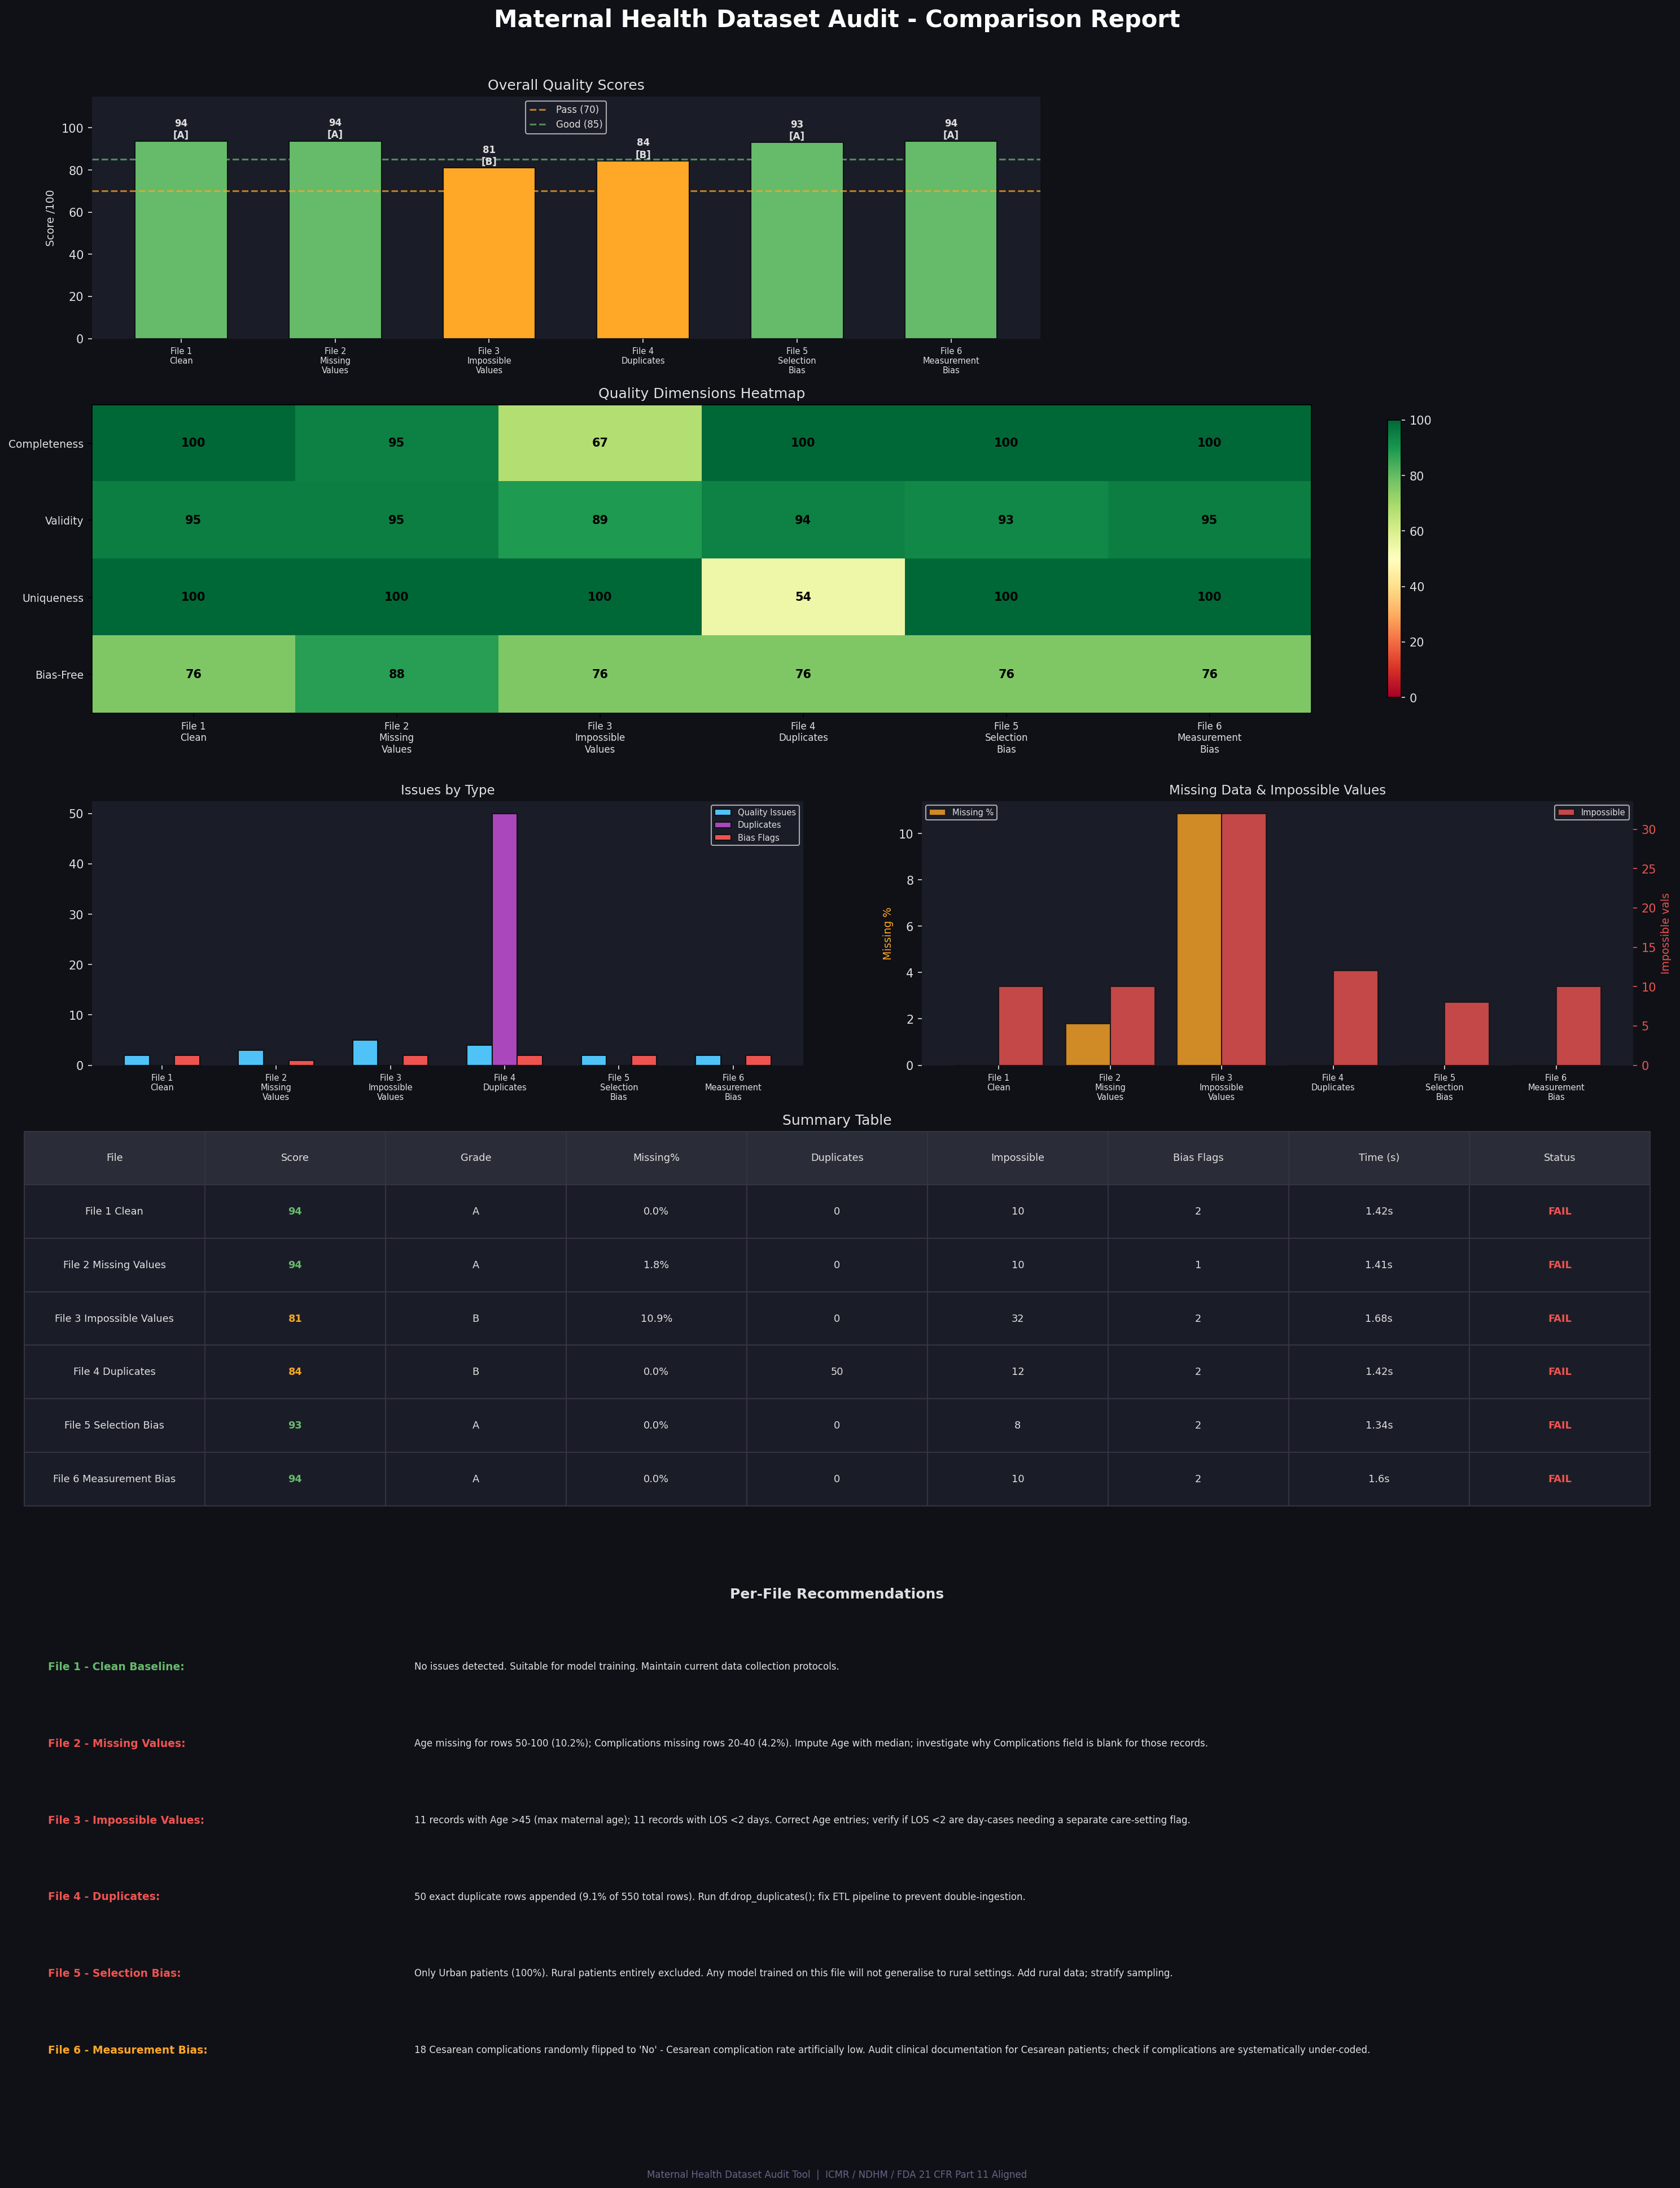

In [ ]:
# Cell 5 - Batch Audit All 6 Files + Comparison Chart
# _Equivalent to running `batch_audit.py`. Audits all 6 files and shows a side-by-side comparison._
#!/usr/bin/env python3
"""
Batch process all 6 maternal health test files and generate a comparison chart.
Usage: python batch_audit.py
"""

import os

import numpy as np


# ─────────────────────────────
#  CONFIG
# ─────────────────────────────

TEST_FILES = [
    ("test_data/test_clean.csv",            "File 1\nClean"),
    ("test_data/test_missing.csv",          "File 2\nMissing\nValues"),
    ("test_data/test_impossible.csv",       "File 3\nImpossible\nValues"),


    ("test_data/test_duplicates.csv",       "File 4\nDuplicates"),
    ("test_data/test_selection_bias.csv",   "File 5\nSelection\nBias"),
    ("test_data/test_measurement_bias.csv", "File 6\nMeasurement\nBias"),
]

REPORT_DIR = "reports"


# ─────────────────────────────
#  RUN ALL AUDITS
# ─────────────────────────────

def run_all_audits():
    """Audit every test file and return a list of (label, result) pairs."""
    print("=" * 65)
    print("  BATCH MATERNAL HEALTH DATASET AUDIT")
    print("=" * 65)

    scanner = DataQualityScanner() # Create an instance of the scanner
    results = []
    for filepath, label in TEST_FILES:
        if not os.path.exists(filepath):
            print(f"  SKIP  {filepath} - file not found")
            continue

        df_to_audit = scanner._load_file(filepath)
        r = scanner.scan_dataframe(
            df          = df_to_audit,
            filepath    = filepath,
            verbose     = False,       # Print score summary to console in batch mode
            save_json   = True,        # Save <filename>_audit.json to reports/
            save_visual = True,        # Generate 8-panel PNG dashboard
            show_inline = False,       # Do not display dashboard inline in batch mode
            output_dir  = REPORT_DIR,
        )

        score  = r["scores"]["overall"]
        grade  = r["scores"]["grade"]
        status = "PASS" if r["scores"]["compliant"] else "FAIL"
        t      = r["processing_time"]

        icon = "✔" if status == "PASS" else "✘"
        print(f"  {icon}  {os.path.basename(filepath):<40}  "
              f"{score:>5.1f}/100  [{grade}]  {status}  ({t}s)")

        results.append((label, r))

    return results


# ────────────────────────────────────────────
#  BUILD COMPARISON CHART
# ────────────────────────────────────────────

def build_comparison_chart(results):
    """
    Produce a single PNG comparing all six files across:
    overall score, quality dimensions (heatmap), issue counts,
    missing rate, a summary table, and per-file recommendations.
    """
    # Access DARK from an instantiated scanner or define it globally if always needed
    # For this function, we'll assume DARK is available (e.g., from an instance or global scope as before)
    # Or, pass it as an argument or re-declare if DataQualityScanner is not instantiated here
    # For simplicity and given the context, let's assume DataQualityScanner.DARK is accessible or passed if needed.
    # If not using an instance, ensure DARK is defined globally or passed.
    # Given the previous cell made DataQualityScanner.DARK available via class attributes,
    # we will refer to it directly as DataQualityScanner.DARK.

    labels   = [lbl for lbl, _ in results]
    overall  = [r["scores"]["overall"]                    for _, r in results]
    comp_s   = [r["scores"]["components"]["completeness"] for _, r in results]
    valid_s  = [r["scores"]["components"]["validity"]     for _, r in results]
    uniq_s   = [r["scores"]["components"]["uniqueness"]   for _, r in results]
    bias_s   = [r["scores"]["components"]["bias_free"]    for _, r in results]
    missing  = [r["summary"]["missing_rate"] * 100        for _, r in results]
    dups     = [r["summary"]["duplicate_rows"]            for _, r in results]
    bias_cnt = [r["summary"]["bias_flags"]                for _, r in results]
    imp_vals = [r["summary"]["impossible_vals"]           for _, r in results]
    times    = [r["processing_time"]                      for _, r in results]

    fig = plt.figure(figsize=(20, 26), facecolor=DataQualityScanner.DARK["bg"])
    fig.suptitle(
        "Maternal Health Dataset Audit - Comparison Report",
        fontsize=20, color="white", fontweight="bold", y=0.99,
    )
    x = np.arange(len(labels))

    # -- Plot 1: Overall scores bar chart ------------------------------
    ax = fig.add_axes([0.06, 0.84, 0.56, 0.11])
    ax.set_facecolor(DataQualityScanner.DARK["card"])
    bars = ax.bar(x, overall, color=[DataQualityScanner()._score_color(s) for s in overall],
                  edgecolor=DataQualityScanner.DARK["bg"], width=0.6)
    ax.axhline(70, color=DataQualityScanner.DARK["yellow"], linestyle="--", alpha=0.7, linewidth=1.5, label="Pass (70)")
    ax.axhline(85, color=DataQualityScanner.DARK["green"],  linestyle="--", alpha=0.7, linewidth=1.5, label="Good (85)")
    for bar, s, (_, r) in zip(bars, overall, results):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{s:.0f}\n[{r['scores']['grade']}]",
                ha="center", va="bottom", color=DataQualityScanner.DARK["text"], fontsize=8, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=DataQualityScanner.DARK["text"], fontsize=7)
    ax.set_ylim(0, 115)
    ax.set_ylabel("Score /100", color=DataQualityScanner.DARK["text"], fontsize=9)
    ax.tick_params(colors=DataQualityScanner.DARK["text"])
    ax.spines[:].set_visible(False)
    ax.legend(facecolor=DataQualityScanner.DARK["card"], labelcolor=DataQualityScanner.DARK["text"], fontsize=8)
    ax.set_title("Overall Quality Scores", color=DataQualityScanner.DARK["text"], fontsize=12, pad=6)

    # -- Plot 2: Quality dimensions heatmap ----------------------------
    ax = fig.add_axes([0.06, 0.67, 0.90, 0.14])
    heat = np.array([comp_s, valid_s, uniq_s, bias_s])
    dim_names = ["Completeness", "Validity", "Uniqueness", "Bias-Free"]
    im = ax.imshow(heat, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, color=DataQualityScanner.DARK["text"], fontsize=8)
    ax.set_yticks(range(len(dim_names)))
    ax.set_yticklabels(dim_names, color=DataQualityScanner.DARK["text"], fontsize=9)
    for i in range(len(dim_names)):
        for j in range(len(labels)):
            val = heat[i, j]
            ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="black" if val > 50 else "white")
    plt.colorbar(im, ax=ax, shrink=0.9).ax.tick_params(colors=DataQualityScanner.DARK["text"])
    ax.set_title("Quality Dimensions Heatmap", color=DataQualityScanner.DARK["text"], fontsize=12, pad=6)

    # -- Plot 3: Issue counts grouped bar ------------------------------
    ax = fig.add_axes([0.06, 0.51, 0.42, 0.12])
    ax.set_facecolor(DataQualityScanner.DARK["card"])
    w = 0.22
    quality_issues = [
        len(r["quality"]["completeness"]["issues"] +
            r["quality"]["validity"]["issues"] +
            r["quality"]["uniqueness"]["issues"] +
            r["quality"]["consistency"]["issues"])
        for _, r in results
    ]
    ax.bar(x - w,     quality_issues, w, label="Quality Issues", color=DataQualityScanner.DARK["blue"],   edgecolor=DataQualityScanner.DARK["bg"])
    ax.bar(x,         dups,           w, label="Duplicates",     color=DataQualityScanner.DARK["purple"], edgecolor=DataQualityScanner.DARK["bg"])
    ax.bar(x + w,     bias_cnt,       w, label="Bias Flags",     color=DataQualityScanner.DARK["red"],    edgecolor=DataQualityScanner.DARK["bg"])
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=DataQualityScanner.DARK["text"], fontsize=7)
    ax.tick_params(colors=DataQualityScanner.DARK["text"])
    ax.spines[:].set_visible(False)
    ax.legend(facecolor=DataQualityScanner.DARK["card"], labelcolor=DataQualityScanner.DARK["text"], fontsize=7)
    ax.set_title("Issues by Type", color=DataQualityScanner.DARK["text"], fontsize=11, pad=6)

    # -- Plot 4: Missing rate + impossible values -----------------------
    ax = fig.add_axes([0.55, 0.51, 0.42, 0.12])
    ax.set_facecolor(DataQualityScanner.DARK["card"])
    ax2 = ax.twinx()
    ax.bar(x,   missing,  0.4, color=DataQualityScanner.DARK["yellow"], alpha=0.8, edgecolor=DataQualityScanner.DARK["bg"], label="Missing %")
    ax2.bar(x + 0.4, imp_vals, 0.4, color=DataQualityScanner.DARK["red"], alpha=0.8, edgecolor=DataQualityScanner.DARK["bg"], label="Impossible")
    ax.set_xticks(x + 0.2)
    ax.set_xticklabels(labels, color=DataQualityScanner.DARK["text"], fontsize=7)
    ax.tick_params(colors=DataQualityScanner.DARK["text"])
    ax2.tick_params(colors=DataQualityScanner.DARK["red"])
    ax.set_ylabel("Missing %",       color=DataQualityScanner.DARK["yellow"], fontsize=9)
    ax2.set_ylabel("Impossible vals", color=DataQualityScanner.DARK["red"],    fontsize=9)
    ax.spines[:].set_visible(False)
    ax2.spines[:].set_visible(False)
    ax.legend(loc="upper left",  facecolor=DataQualityScanner.DARK["card"], labelcolor=DataQualityScanner.DARK["text"], fontsize=7)
    ax2.legend(loc="upper right", facecolor=DataQualityScanner.DARK["card"], labelcolor=DataQualityScanner.DARK["text"], fontsize=7)
    ax.set_title("Missing Data & Impossible Values", color=DataQualityScanner.DARK["text"], fontsize=11, pad=6)

    # -- Plot 5: Summary table -----------------------------------------
    ax = fig.add_axes([0.02, 0.31, 0.96, 0.17])
    ax.set_facecolor(DataQualityScanner.DARK["card"])
    ax.axis("off")
    headers = ["File", "Score", "Grade", "Missing%", "Duplicates",
               "Impossible", "Bias Flags", "Time (s)", "Status"]
    rows = []
    for lbl, r in results:
        m = r["summary"]
        rows.append([
            lbl.replace("\n", " "),
            f"{r['scores']['overall']:.0f}",
            r["scores"]["grade"],
            f"{m['missing_rate']*100:.1f}%",
            str(m["duplicate_rows"]),
            str(m["impossible_vals"]),
            str(m["bias_flags"]),
            f"{r['processing_time']}s",
            "PASS" if r["scores"]["compliant"] else "FAIL",
        ])

    # Handle case where results is empty to prevent IndexError
    if not rows:
        rows = [["N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A"]]

    tbl = ax.table(cellText=rows, colLabels=headers,
                   cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    for (ri, ci), cell in tbl.get_celld().items():
        cell.set_facecolor("#2a2d37" if ri == 0 else DataQualityScanner.DARK["card"])
        cell.set_text_props(color=DataQualityScanner.DARK["text"])
        cell.set_edgecolor("#333344")
        if ri > 0 and len(results) > 0: # Ensure results is not empty before accessing
            if ci == 1:  # score
                c = DataQualityScanner()._score_color(float(rows[ri-1][1]))
                cell.set_text_props(color=c, fontweight="bold")
            if ci == 8:  # status
                c = DataQualityScanner.DARK["green"] if rows[ri-1][8] == "PASS" else DataQualityScanner.DARK["red"]
                cell.set_text_props(color=c, fontweight="bold")
    ax.set_title("Summary Table", color=DataQualityScanner.DARK["text"], fontsize=12, pad=6)

    # -- Plot 6: Recommendations ----------------------------------------
    ax = fig.add_axes([0.02, 0.04, 0.96, 0.24])
    ax.set_facecolor(DataQualityScanner.DARK["card"])
    ax.axis("off")
    recs = [
        ("File 1 - Clean Baseline",       "green",
         "No issues detected. Suitable for model training. Maintain current data collection protocols."),
        ("File 2 - Missing Values",        "red",
         "Age missing for rows 50-100 (10.2%); Complications missing rows 20-40 (4.2%). "
         "Impute Age with median; investigate why Complications field is blank for those records."),
        ("File 3 - Impossible Values",     "red",
         "11 records with Age >45 (max maternal age); 11 records with LOS <2 days. "
         "Correct Age entries; verify if LOS <2 are day-cases needing a separate care-setting flag."),
        ("File 4 - Duplicates",            "red",
         "50 exact duplicate rows appended (9.1% of 550 total rows). "
         "Run df.drop_duplicates(); fix ETL pipeline to prevent double-ingestion."),
        ("File 5 - Selection Bias",        "red",
         "Only Urban patients (100%). Rural patients entirely excluded. "
         "Any model trained on this file will not generalise to rural settings. Add rural data; stratify sampling."),
        ("File 6 - Measurement Bias",      "yellow",
         "18 Cesarean complications randomly flipped to 'No' - Cesarean complication rate artificially low. "
         "Audit clinical documentation for Cesarean patients; check if complications are systematically under-coded."),
    ]
    ax.text(0.5, 0.97, "Per-File Recommendations",
            ha="center", va="top", color=DataQualityScanner.DARK["text"], fontsize=12,
            fontweight="bold", transform=ax.transAxes)
    for i, (title, color, text) in enumerate(recs):
        hex_c = {"green": DataQualityScanner.DARK["green"], "red": DataQualityScanner.DARK["red"], "yellow": DataQualityScanner.DARK["yellow"]}[color]
        y = 0.83 - i * 0.145
        ax.text(0.01, y, f"  {title}:", color=hex_c, fontsize=9,
                fontweight="bold", transform=ax.transAxes, va="top")
        ax.text(0.24, y, text, color=DataQualityScanner.DARK["text"], fontsize=8,
                transform=ax.transAxes, va="top")

    fig.text(0.5, 0.005,
             "Maternal Health Dataset Audit Tool  |  ICMR / NDHM / FDA 21 CFR Part 11 Aligned",
             ha="center", color="#666688", fontsize=8)

    out_path = os.path.join(REPORT_DIR, "comparison_report.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=DataQualityScanner.DARK["bg"])
    plt.close()
    return out_path


# ───────────────────────────
#  ENTRY POINT
# ───────────────────────────


# --- Run everything -------------------------------------------------------
os.makedirs(REPORT_DIR, exist_ok=True)
results    = run_all_audits()
chart_path = build_comparison_chart(results)

print(f'\n✔ Comparison chart -> {chart_path}')
print(f'✔ All JSON + PNG reports in ./reports/')

# Display comparison chart inline
from IPython.display import display, Image as IPImage
display(IPImage(chart_path, width=950))

In [ ]:
# Cell 6 - Download All Reports
#Packages every JSON result + PNG dashboard into a single ZIP and downloads it.
import zipfile
from google.colab import files as colab_files

zip_path = 'audit_reports.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, _, filenames in os.walk('reports'):
        for fname in sorted(filenames):
            fpath = os.path.join(root, fname)
            zf.write(fpath)
            print(f'  Added: {fpath}')

print(f'\n✔ ZIP created: {zip_path}')
colab_files.download(zip_path)

  Added: reports/comparison_report.png
  Added: reports/test_clean_audit.json
  Added: reports/test_clean_report.png
  Added: reports/test_duplicates_audit.json
  Added: reports/test_duplicates_report.png
  Added: reports/test_impossible_audit.json
  Added: reports/test_impossible_report.png
  Added: reports/test_measurement_bias_audit.json
  Added: reports/test_measurement_bias_report.png
  Added: reports/test_missing_audit.json
  Added: reports/test_missing_report.png
  Added: reports/test_selection_bias_audit.json
  Added: reports/test_selection_bias_report.png

✔ ZIP created: audit_reports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Fixing Flagged Issues: Practical Examples

Based on the audit, here are common fixes for some flagged issues. We'll apply these to a copy of the `df_maternity` DataFrame to demonstrate.

In [ ]:
# step 7: fixing the flagged issues
# Create a copy of the maternity dataframe to apply fixes
df_fixed = df_maternity.copy()

In [ ]:
# Simulate missing values for demonstration (these were in test_missing.csv)
# Let's say Age was missing for index 50-100
df_fixed.loc[50:100, 'Age'] = np.nan
# And Complications for index 20-40
df_fixed.loc[20:40, 'Complications'] = np.nan

print("Original missing Age count:", df_fixed['Age'].isnull().sum())
print("Original missing Complications count:", df_fixed['Complications'].isnull().sum())

# Fix: Impute 'Age' with its median
median_age = df_fixed['Age'].median()
df_fixed['Age'].fillna(median_age, inplace=True)

# Fix: Impute 'Complications' with its mode
mode_complications = df_fixed['Complications'].mode()[0]
df_fixed['Complications'].fillna(mode_complications, inplace=True)

print("Missing Age count after imputation:", df_fixed['Age'].isnull().sum())
print("Missing Complications count after imputation:", df_fixed['Complications'].isnull().sum())


Original missing Age count: 51
Original missing Complications count: 21
Missing Age count after imputation: 0
Missing Complications count after imputation: 0


In [ ]:
# Simulate impossible values for demonstration (these were in test_impossible.csv)
# Let's set some ages > 45 (e.g., 50) and < 18 (e.g., 5)
df_fixed.loc[10:12, 'Age'] = 50
df_fixed.loc[13:14, 'Age'] = 5

# Let's set some LOS < 2
df_fixed.loc[30:32, 'LengthofStaydays'] = 1

print("Original Age > 45 count:", (df_fixed['Age'] > 45).sum())
print("Original Age < 18 count:", (df_fixed['Age'] < 18).sum())
print("Original LOS < 2 count:", (df_fixed['LengthofStaydays'] < 2).sum())

# Fix: Cap 'Age' to be within valid range (18-45)
valid_age_min, valid_age_max = 18, 45 # Using 18-45 as per corrected VALID_RANGES
df_fixed['Age'] = df_fixed['Age'].clip(lower=valid_age_min, upper=valid_age_max)

# Fix: Cap 'LengthofStaydays' to be at least 2
valid_los_min = 2
df_fixed['LengthofStaydays'] = df_fixed['LengthofStaydays'].clip(lower=valid_los_min)

print("Age > 45 count after correction:", (df_fixed['Age'] > 45).sum())
print("Age < 18 count after correction:", (df_fixed['Age'] < 18).sum())
print("LOS < 2 count after correction:", (df_fixed['LengthofStaydays'] < 2).sum())


Original Age > 45 count: 5
Original Age < 18 count: 10
Original LOS < 2 count: 4
Age > 45 count after correction: 0
Age < 18 count after correction: 0
LOS < 2 count after correction: 0


In [ ]:
# Simulate duplicate rows for demonstration
df_fixed_with_dups = pd.concat([df_fixed, df_fixed.iloc[:5]], ignore_index=True)

print("Total rows before removing duplicates:", len(df_fixed_with_dups))
print("Duplicate rows before removing duplicates:", df_fixed_with_dups.duplicated().sum())

# Fix: Remove duplicate rows
df_fixed_deduped = df_fixed_with_dups.drop_duplicates()

print("Total rows after removing duplicates:", len(df_fixed_deduped))
print("Duplicate rows after removing duplicates:", df_fixed_deduped.duplicated().sum())


Total rows before removing duplicates: 505
Duplicate rows before removing duplicates: 5
Total rows after removing duplicates: 500
Duplicate rows after removing duplicates: 0



  MATERNAL HEALTH DATASET AUDIT - test_fixed.csv


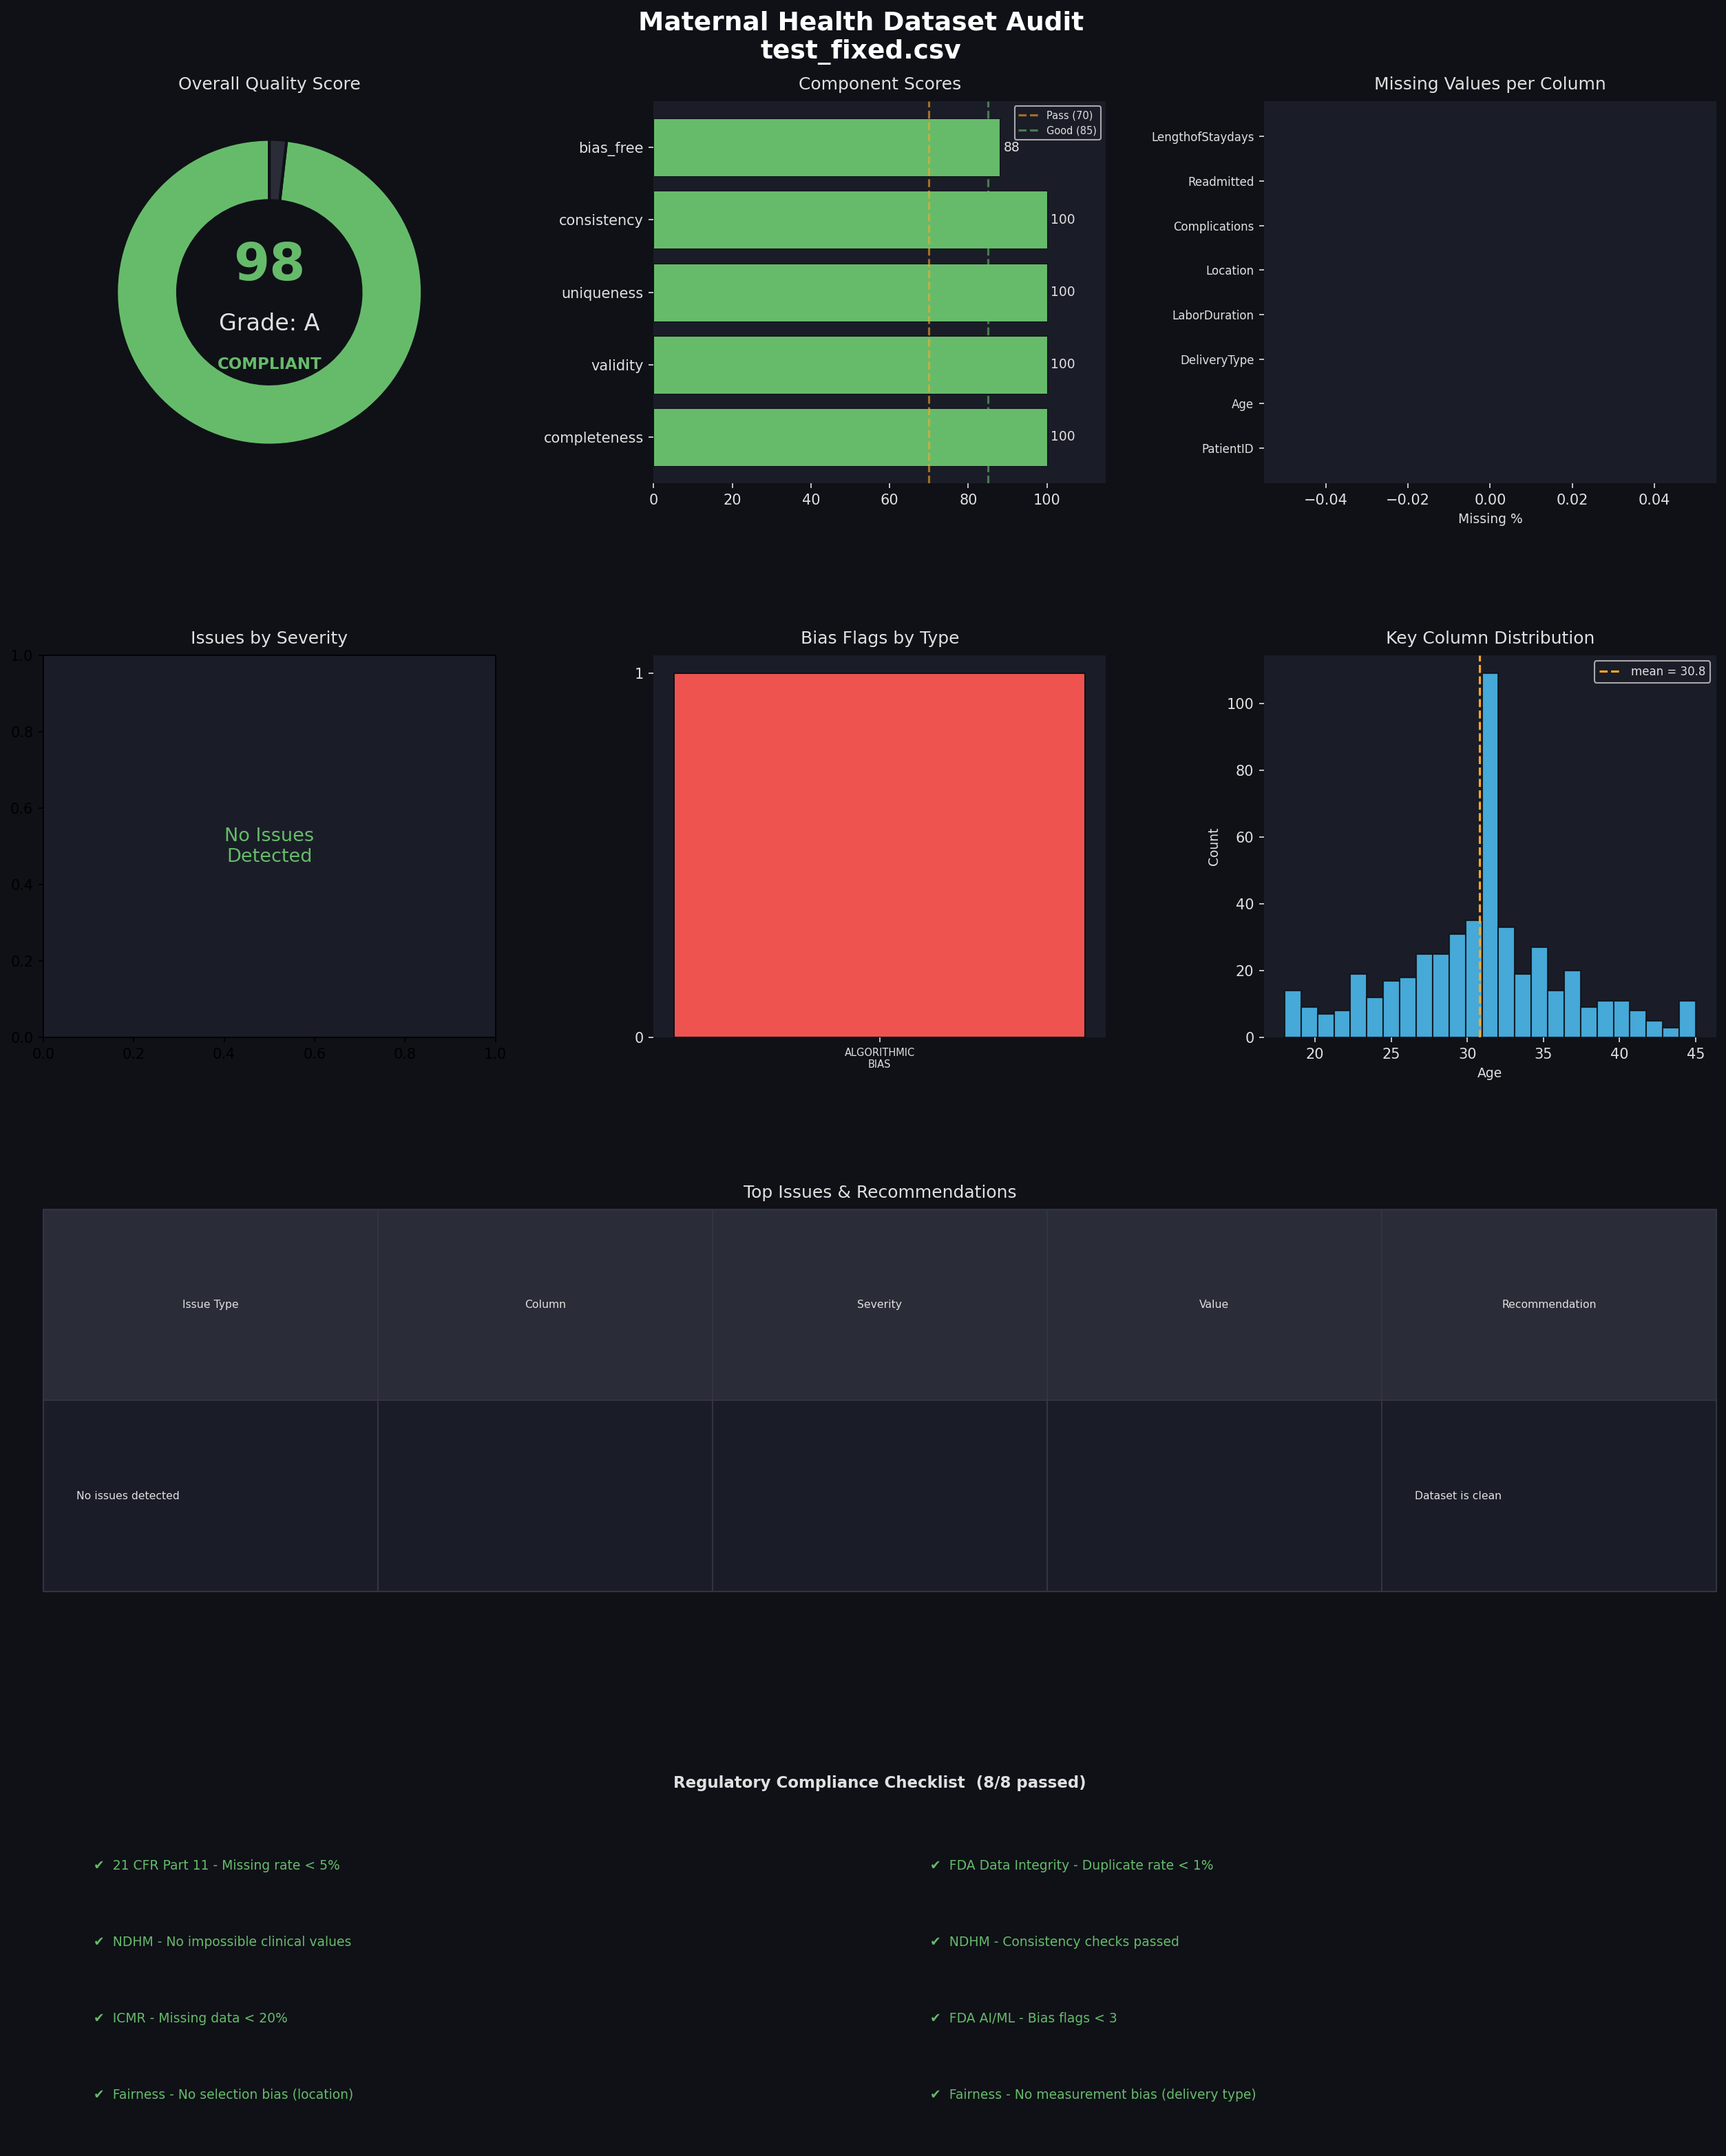

  JSON results  -> reports/test_fixed_audit.json

────────────────────────────────────────────────────────────
  SCORE: 98.2/100  [Grade A]  COMPLIANT
────────────────────────────────────────────────────────────
  completeness   ██████████  100.0/100
  validity       ██████████  100.0/100
  uniqueness     ██████████  100.0/100
  consistency    ██████████  100.0/100
  bias_free      ████████░░   88.0/100
────────────────────────────────────────────────────────────
  Quality issues : 0
  Bias flags     : 1
  Missing rate   : 0.0%
  Duplicates     : 0
  Impossible vals: 0
  Time           : 1.73s



In [ ]:
#REAUDIT THE DATASET
scanner = DataQualityScanner()

result_fixed = scanner.scan_dataframe(
    df          = df_fixed_deduped,
    filepath    = 'test_data/test_fixed.csv', # Use a new filename for the fixed data
    verbose     = True,
    save_json   = True,
    save_visual = True,
    show_inline = True,
    output_dir  = 'reports',
)